# Figure 3

Computational panels B–E and G–L.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
import os
from pathlib import Path

# Locate the repository whether the notebook is run from the repo root or notebook/.
_start = Path.cwd().resolve()
ROOT = next(
    candidate
    for candidate in (_start, *_start.parents)
    if (candidate / "environment.yml").is_file()
)

# Override this environment variable when the shared data directory is mounted elsewhere.
DATA_ROOT = Path(
    os.environ.get("BIOAGENTS_DATA_ROOT", "/gpfs/group/jin/asun/bioagents/data")
)
DEG_PATH = DATA_ROOT / "wilcoxon_de_results_group_name_final_data_no_multi_guide_cells.parquet"
REPORTS_PATH = DATA_ROOT / "perturbai_reports" / "reports" / "html"


In [2]:
from pathlib import Path

import matplotlib as mpl

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle

In [3]:
_HERE = ROOT
_ROOT = next((candidate for candidate in (_HERE, *_HERE.parents) if (candidate / 'environment.yml').is_file()))
_DATA_DIR = _ROOT / 'src' / 'manuscript_figures' / 'fig3'
_OUTPUT_DIR = _DATA_DIR / 'generated'
_STYLE = _ROOT / 'src' / 'manuscript_figures' / 'style.mplstyle'
if _STYLE.is_file():
    plt.style.use(_STYLE)
mpl.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white', 'figure.dpi': 150, 'savefig.dpi': 300, 'svg.fonttype': 'none', 'pdf.fonttype': 42, 'text.parse_math': False})
_CHROME = {'ink': '#222222', 'muted': '#666666', 'axis': '#9ca3af', 'grid': '#e2e4e7', 'link': '#c7cdd6', 'observed': '#59636f', 'bioagents': '#00838f', 'error': '#d94841', 'purple': '#6b5a8e', 'orange': '#e69f00'}
_NETWORK_COLORS = {'functional': '#377eb8', 'physical': '#4e914f', 'literature': '#b54878'}
_NETWORK_LABELS = {'functional': 'Functional', 'physical': 'Physical', 'literature': 'Text-mining'}
_b = pd.read_csv(_DATA_DIR / 'b' / 'analysis' / 'task1_deg_count_comparison.csv')
_c = pd.read_csv(_DATA_DIR / 'c' / 'analysis' / 'task1_per_target.csv')
_d = pd.read_csv(_DATA_DIR / 'd' / 'analysis' / 'stratified_bucket_summary.csv')
_e_cases = pd.read_csv(_DATA_DIR / 'e' / 'source_outputs' / 'featured_cases.csv')
_e_anchors = pd.read_csv(_DATA_DIR / 'e' / 'source_outputs' / 'trace_anchors.csv')
_g = pd.read_csv(_DATA_DIR / 'g' / 'source_outputs' / 'top6_zero_miss_string_buckets.csv')
_h = pd.read_csv(_DATA_DIR / 'h' / 'source_outputs' / 'featured_overpredictions.csv')
_j = pd.read_csv(_DATA_DIR / 'j' / 'source_outputs' / 'gt_ranking_data.csv')
_k = pd.read_csv(_DATA_DIR / 'k' / 'source_outputs' / 'depletion-best-vs-codex-heldout-recall.tsv', sep='\t')
_l = pd.read_csv(_DATA_DIR / 'l' / 'source_outputs' / 'prediction_annotations.csv')

def _heading(container, letter, title):
    container.suptitle(f'{letter}   {title}', x=0.02, y=0.995, ha='left', va='top', fontsize=10.5, fontweight='bold', color=_CHROME['ink'])

def _clean_axis(ax, grid_axis=None):
    ax.spines[['top', 'right']].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(_CHROME['axis'])
        ax.spines[side].set_linewidth(0.55)
    ax.tick_params(length=2.5, width=0.5, colors=_CHROME['muted'])
    if grid_axis:
        ax.grid(axis=grid_axis, color=_CHROME['grid'], linewidth=0.55)
        ax.set_axisbelow(True)

NOTEBOOK_SIZE_SCALE = 1.45
NOTEBOOK_FONT_SCALE = 1.15

def save_panel(letter, drawer, size):
    # Expand paper-sized panels for legible inline inspection.
    notebook_size = tuple(value * NOTEBOOK_SIZE_SCALE for value in size)
    figure = plt.figure(figsize=notebook_size)
    drawer(figure)
    for text in figure.findobj(match=mpl.text.Text):
        text.set_fontsize(text.get_fontsize() * NOTEBOOK_FONT_SCALE)
    return (figure, [])
B_DATA = _b
C_DATA = _c
CHROME = _CHROME
D_DATA = _d
E_ANCHORS = _e_anchors
E_CASES = _e_cases
G_DATA = _g
H_DATA = _h
J_DATA = _j
K_DATA = _k
L_DATA = _l
NETWORK_COLORS = _NETWORK_COLORS
NETWORK_LABELS = _NETWORK_LABELS
clean_axis = _clean_axis
heading = _heading
output_dir = _OUTPUT_DIR
repo_root = _ROOT

## Figure 3B

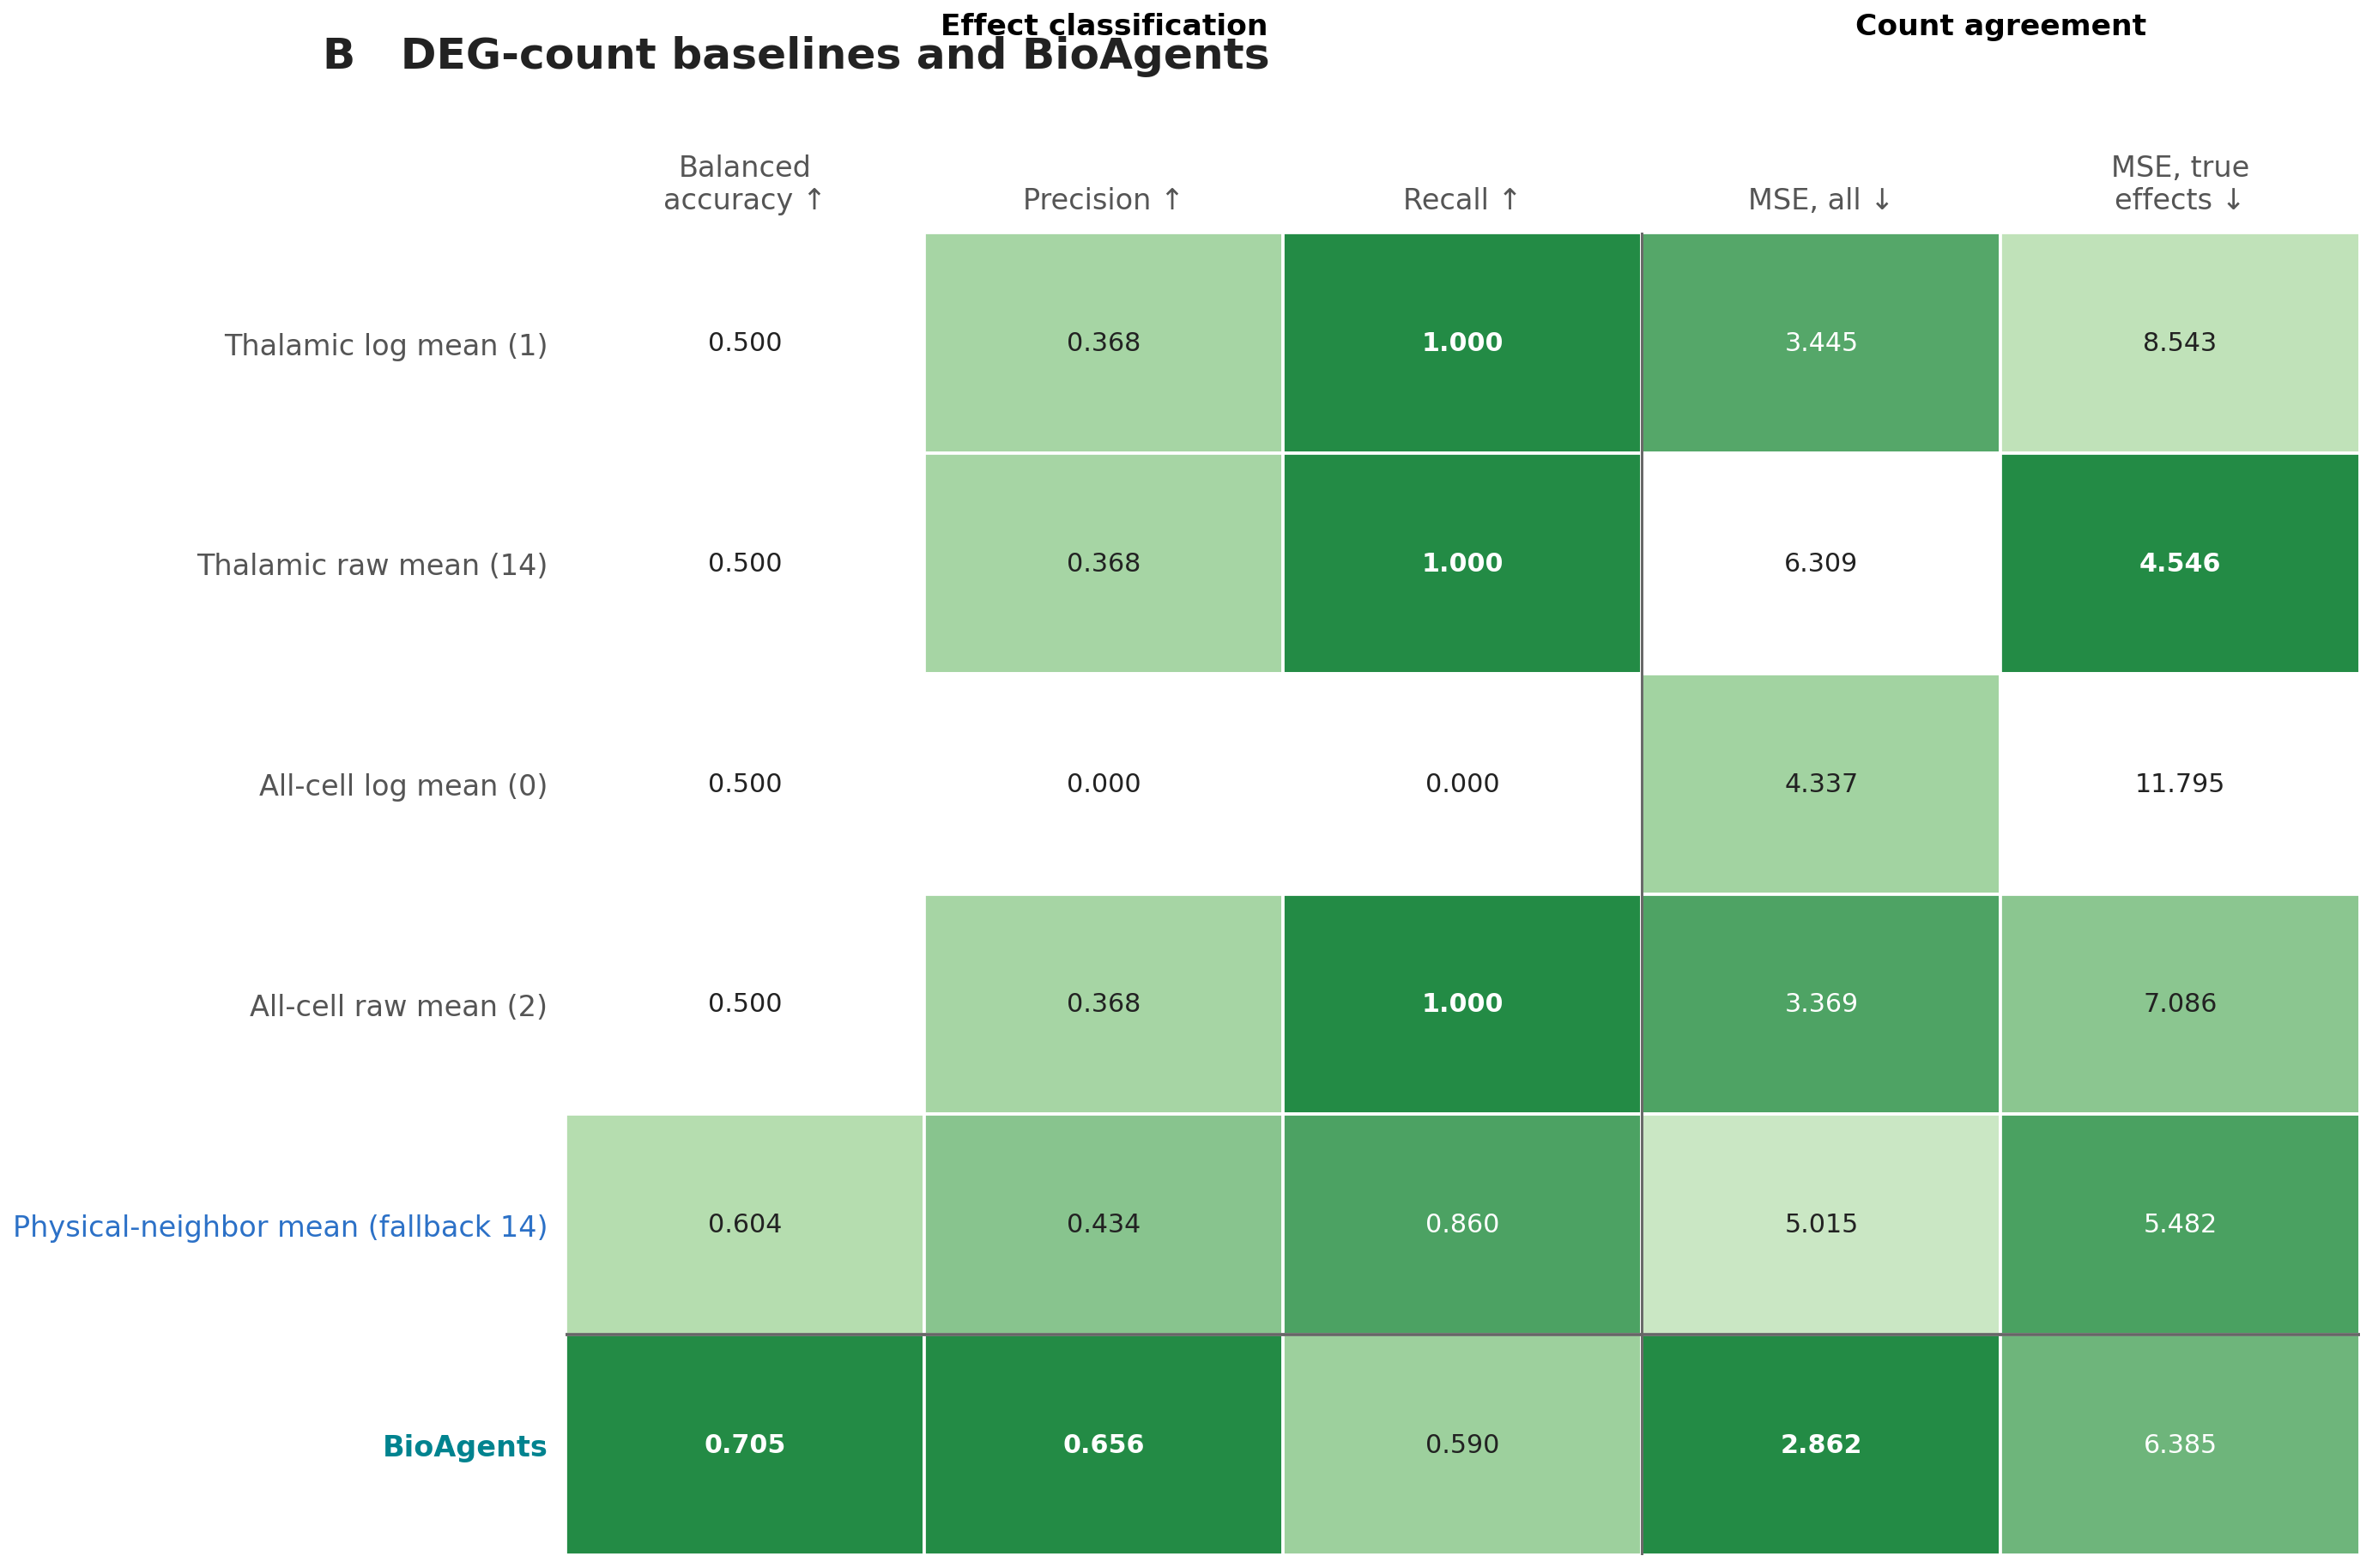

In [4]:
_CHROME = CHROME
_heading = heading
_methods = (
    "constant_log_mse",
    "constant_arithmetic_mean",
    "all_cell_types_constant_log_mse",
    "all_cell_types_constant_arithmetic_mean",
    "physical_neighbor_mean_count",
)
_labels = (
    "Thalamic log mean (1)",
    "Thalamic raw mean (14)",
    "All-cell log mean (0)",
    "All-cell raw mean (2)",
    "Physical-neighbor mean (fallback 14)",
    "BioAgents",
)
_baselines = B_DATA[
    B_DATA["system"].eq("baseline") & B_DATA["method"].isin(_methods)
].set_index("method").loc[list(_methods)]
_bioagents = B_DATA[B_DATA["system"].eq("bioagents")].iloc[[0]]
_frame = pd.concat([_baselines.reset_index(), _bioagents], ignore_index=True)
_metrics = (
    ("balanced_accuracy", "Balanced\naccuracy ↑", "high"),
    ("precision", "Precision ↑", "high"),
    ("recall", "Recall ↑", "high"),
    ("mse_log1p_all", "MSE, all ↓", "low"),
    ("mse_log1p_true_effect", "MSE, true\neffects ↓", "low"),
)
_values = _frame[[metric[0] for metric in _metrics]].to_numpy(dtype=float)
_quality = np.full_like(_values, np.nan)
for _column, (_, _, _direction) in enumerate(_metrics):
    _raw = _values[:, _column]
    _low, _high = np.nanmin(_raw), np.nanmax(_raw)
    _scaled = (_raw - _low) / (_high - _low) if _high != _low else np.full_like(_raw, 0.25)
    _quality[:, _column] = _scaled if _direction == "high" else 1 - _scaled
_cmap = mcolors.LinearSegmentedColormap.from_list(
    "fig3_quality", ("#ffffff", "#b8dfb1", "#238b45")
)

# ------------------------------------------------------------------ B
def draw_b(container):
    _heading(container, "B", "DEG-count baselines and BioAgents")
    ax = container.subplots()
    for _row in range(len(_labels)):
        for _column in range(len(_metrics)):
            _value = _values[_row, _column]
            _q = _quality[_row, _column]
            ax.add_patch(
                Rectangle(
                    (_column - 0.5, _row - 0.5),
                    1,
                    1,
                    facecolor=_cmap(_q),
                    edgecolor="white",
                    linewidth=0.9,
                )
            )
            ax.text(
                _column,
                _row,
                f"{_value:.3f}",
                ha="center",
                va="center",
                fontsize=6.3,
                color="white" if _q > 0.72 else _CHROME["ink"],
                fontweight="bold" if np.isclose(_q, 1.0) else "normal",
            )
    ax.set_xlim(-0.5, len(_metrics) - 0.5)
    ax.set_ylim(len(_labels) - 0.5, -0.5)
    ax.set_xticks(
        np.arange(len(_metrics)),
        [metric[1] for metric in _metrics],
    )
    ax.xaxis.tick_top()
    ax.tick_params(axis="x", length=0, pad=5)
    ax.set_yticks(np.arange(len(_labels)), _labels)
    ax.tick_params(axis="y", length=0, pad=5)
    ax.get_yticklabels()[-1].set_color(_CHROME["bioagents"])
    ax.get_yticklabels()[-1].set_fontweight("bold")
    ax.get_yticklabels()[-2].set_color("#2c71c7")
    ax.axvline(2.5, color=_CHROME["muted"], linewidth=0.7)
    ax.axhline(4.5, color=_CHROME["muted"], linewidth=0.9)
    ax.text(
        1,
        1.15,
        "Effect classification",
        transform=ax.get_xaxis_transform(),
        ha="center",
        fontsize=7.2,
        fontweight="bold",
    )
    ax.text(
        3.5,
        1.15,
        "Count agreement",
        transform=ax.get_xaxis_transform(),
        ha="center",
        fontsize=7.2,
        fontweight="bold",
    )
    for _spine in ax.spines.values():
        _spine.set_visible(False)
    # A metric table yields the square-panel rule: long row labels require
    # its natural rectangular aspect to keep the cells and text legible.

fig_b, outputs_b = save_panel("B", draw_b, (6.2, 4.6))
fig_b;

## Figure 3C

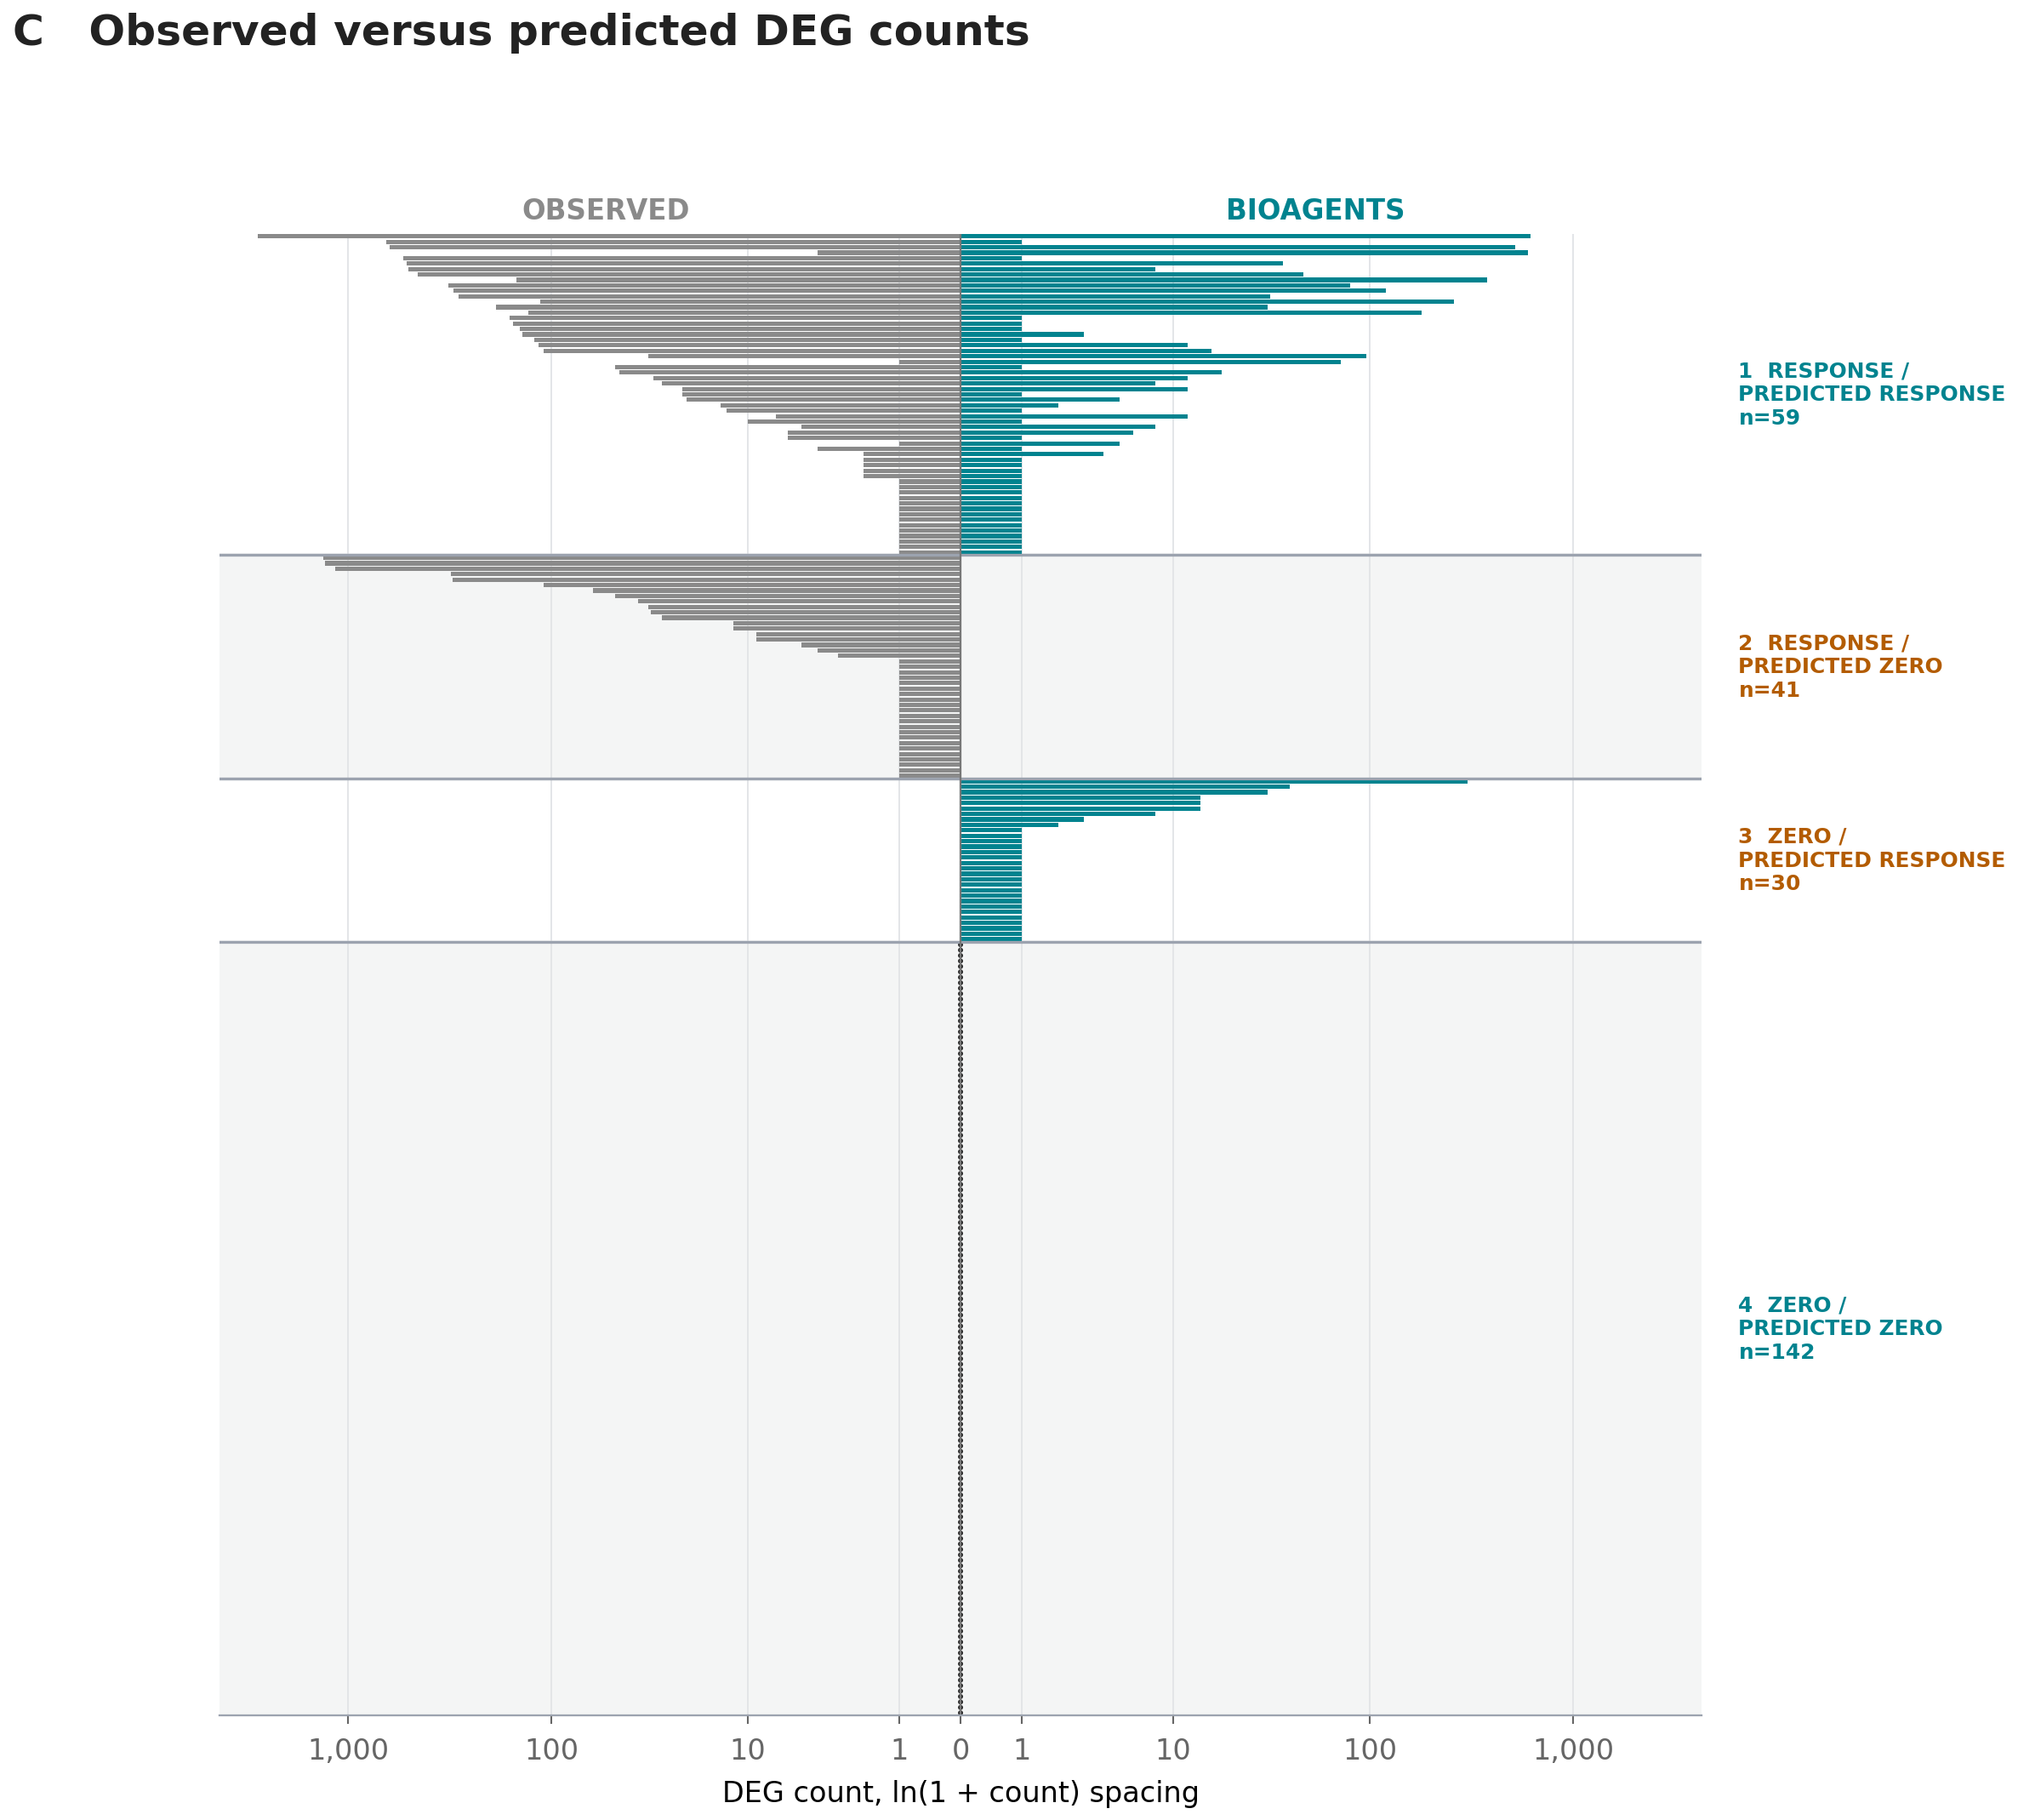

In [5]:
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading
_frame = C_DATA[["target_name", "actual_n_degs", "bioagents_predicted_n_degs"]].copy()
_nup93 = _frame["target_name"].eq("Nup93")
if int(_frame.loc[_nup93, "bioagents_predicted_n_degs"].iloc[0]) != 620:
    raise ValueError("Nup93 source prediction changed from the retained value 620")
_frame.loc[_nup93, "bioagents_predicted_n_degs"] = 0
_actual_positive = _frame["actual_n_degs"].gt(0)
_predicted_positive = _frame["bioagents_predicted_n_degs"].gt(0)
_frame["group"] = np.select(
    (
        _actual_positive & _predicted_positive,
        _actual_positive & ~_predicted_positive,
        ~_actual_positive & _predicted_positive,
    ),
    (1, 2, 3),
    default=4,
)
_frame["largest"] = _frame[["actual_n_degs", "bioagents_predicted_n_degs"]].max(axis=1)
_frame = _frame.sort_values(
    ["group", "largest", "actual_n_degs", "bioagents_predicted_n_degs", "target_name"],
    ascending=[True, False, False, False, True],
).reset_index(drop=True)
_group_labels = {
    1: "1  RESPONSE /\nPREDICTED RESPONSE",
    2: "2  RESPONSE /\nPREDICTED ZERO",
    3: "3  ZERO /\nPREDICTED RESPONSE",
    4: "4  ZERO /\nPREDICTED ZERO",
}

# ------------------------------------------------------------------ C
def draw_c(container):
    _heading(container, "C", "Observed versus predicted DEG counts")
    ax = container.subplots()
    _y = np.arange(len(_frame), dtype=float)
    _actual = _frame["actual_n_degs"].to_numpy(dtype=float)
    _predicted = _frame["bioagents_predicted_n_degs"].to_numpy(dtype=float)
    _actual_width = np.log1p(_actual)
    _predicted_width = np.log1p(_predicted)
    _start = 0
    for _group in range(1, 5):
        _count = int(_frame["group"].eq(_group).sum())
        _stop = _start + _count
        if _group in (2, 4):
            ax.axhspan(_start - 0.5, _stop - 0.5, color="#f4f5f5", zorder=0)
        ax.text(
            1.025,
            (_start + _stop - 1) / 2,
            f"{_group_labels[_group]}\nn={_count}",
            transform=ax.get_yaxis_transform(),
            ha="left",
            va="center",
            fontsize=5.2,
            fontweight="bold",
            color=_CHROME["bioagents"] if _group in (1, 4) else "#b35c00",
            clip_on=False,
        )
        if _group < 4:
            ax.axhline(_stop - 0.5, color=_CHROME["axis"], linewidth=0.8)
        _start = _stop
    ax.barh(
        _y,
        _actual_width,
        left=-_actual_width,
        height=0.80,
        color="#8a8a8a",
        edgecolor="none",
    )
    ax.barh(
        _y,
        _predicted_width,
        height=0.80,
        color=_CHROME["bioagents"],
        edgecolor="none",
    )
    _double_zero = (_actual == 0) & (_predicted == 0)
    ax.scatter(
        np.zeros(int(_double_zero.sum())),
        _y[_double_zero],
        s=2,
        color=_CHROME["ink"],
        edgecolor="none",
        clip_on=False,
    )
    _ticks = np.asarray([1, 10, 100, 1000], dtype=float)
    _positions = [-np.log1p(value) for value in _ticks[::-1]] + [0.0] + [
        np.log1p(value) for value in _ticks
    ]
    _tick_labels = ["1,000", "100", "10", "1", "0", "1", "10", "100", "1,000"]
    ax.set_xticks(_positions, _tick_labels)
    _extent = np.log1p(max(float(_actual.max()), float(_predicted.max()), 3000)) + 0.35
    ax.set_xlim(-_extent, _extent)
    ax.set_ylim(len(_frame) - 0.5, -0.5)
    ax.set_yticks([])
    ax.axvline(0, color="#777777", linewidth=0.55)
    for _tick in _ticks:
        _distance = np.log1p(_tick)
        ax.axvline(-_distance, color=_CHROME["grid"], linewidth=0.45, zorder=0)
        ax.axvline(_distance, color=_CHROME["grid"], linewidth=0.45, zorder=0)
    _side_center = np.log1p(3000) / 2
    ax.text(
        -_side_center,
        1.01,
        "OBSERVED",
        transform=ax.get_xaxis_transform(),
        ha="center",
        fontsize=6.8,
        fontweight="bold",
        color="#8a8a8a",
    )
    ax.text(
        _side_center,
        1.01,
        "BIOAGENTS",
        transform=ax.get_xaxis_transform(),
        ha="center",
        fontsize=6.8,
        fontweight="bold",
        color=_CHROME["bioagents"],
    )
    ax.set_xlabel("DEG count, ln(1 + count) spacing")
    _clean_axis(ax)
    ax.spines["left"].set_visible(False)
    ax.set_box_aspect(1)

fig_c, outputs_c = save_panel("C", draw_c, (5.2, 5.2))
fig_c;

## Figure 3D

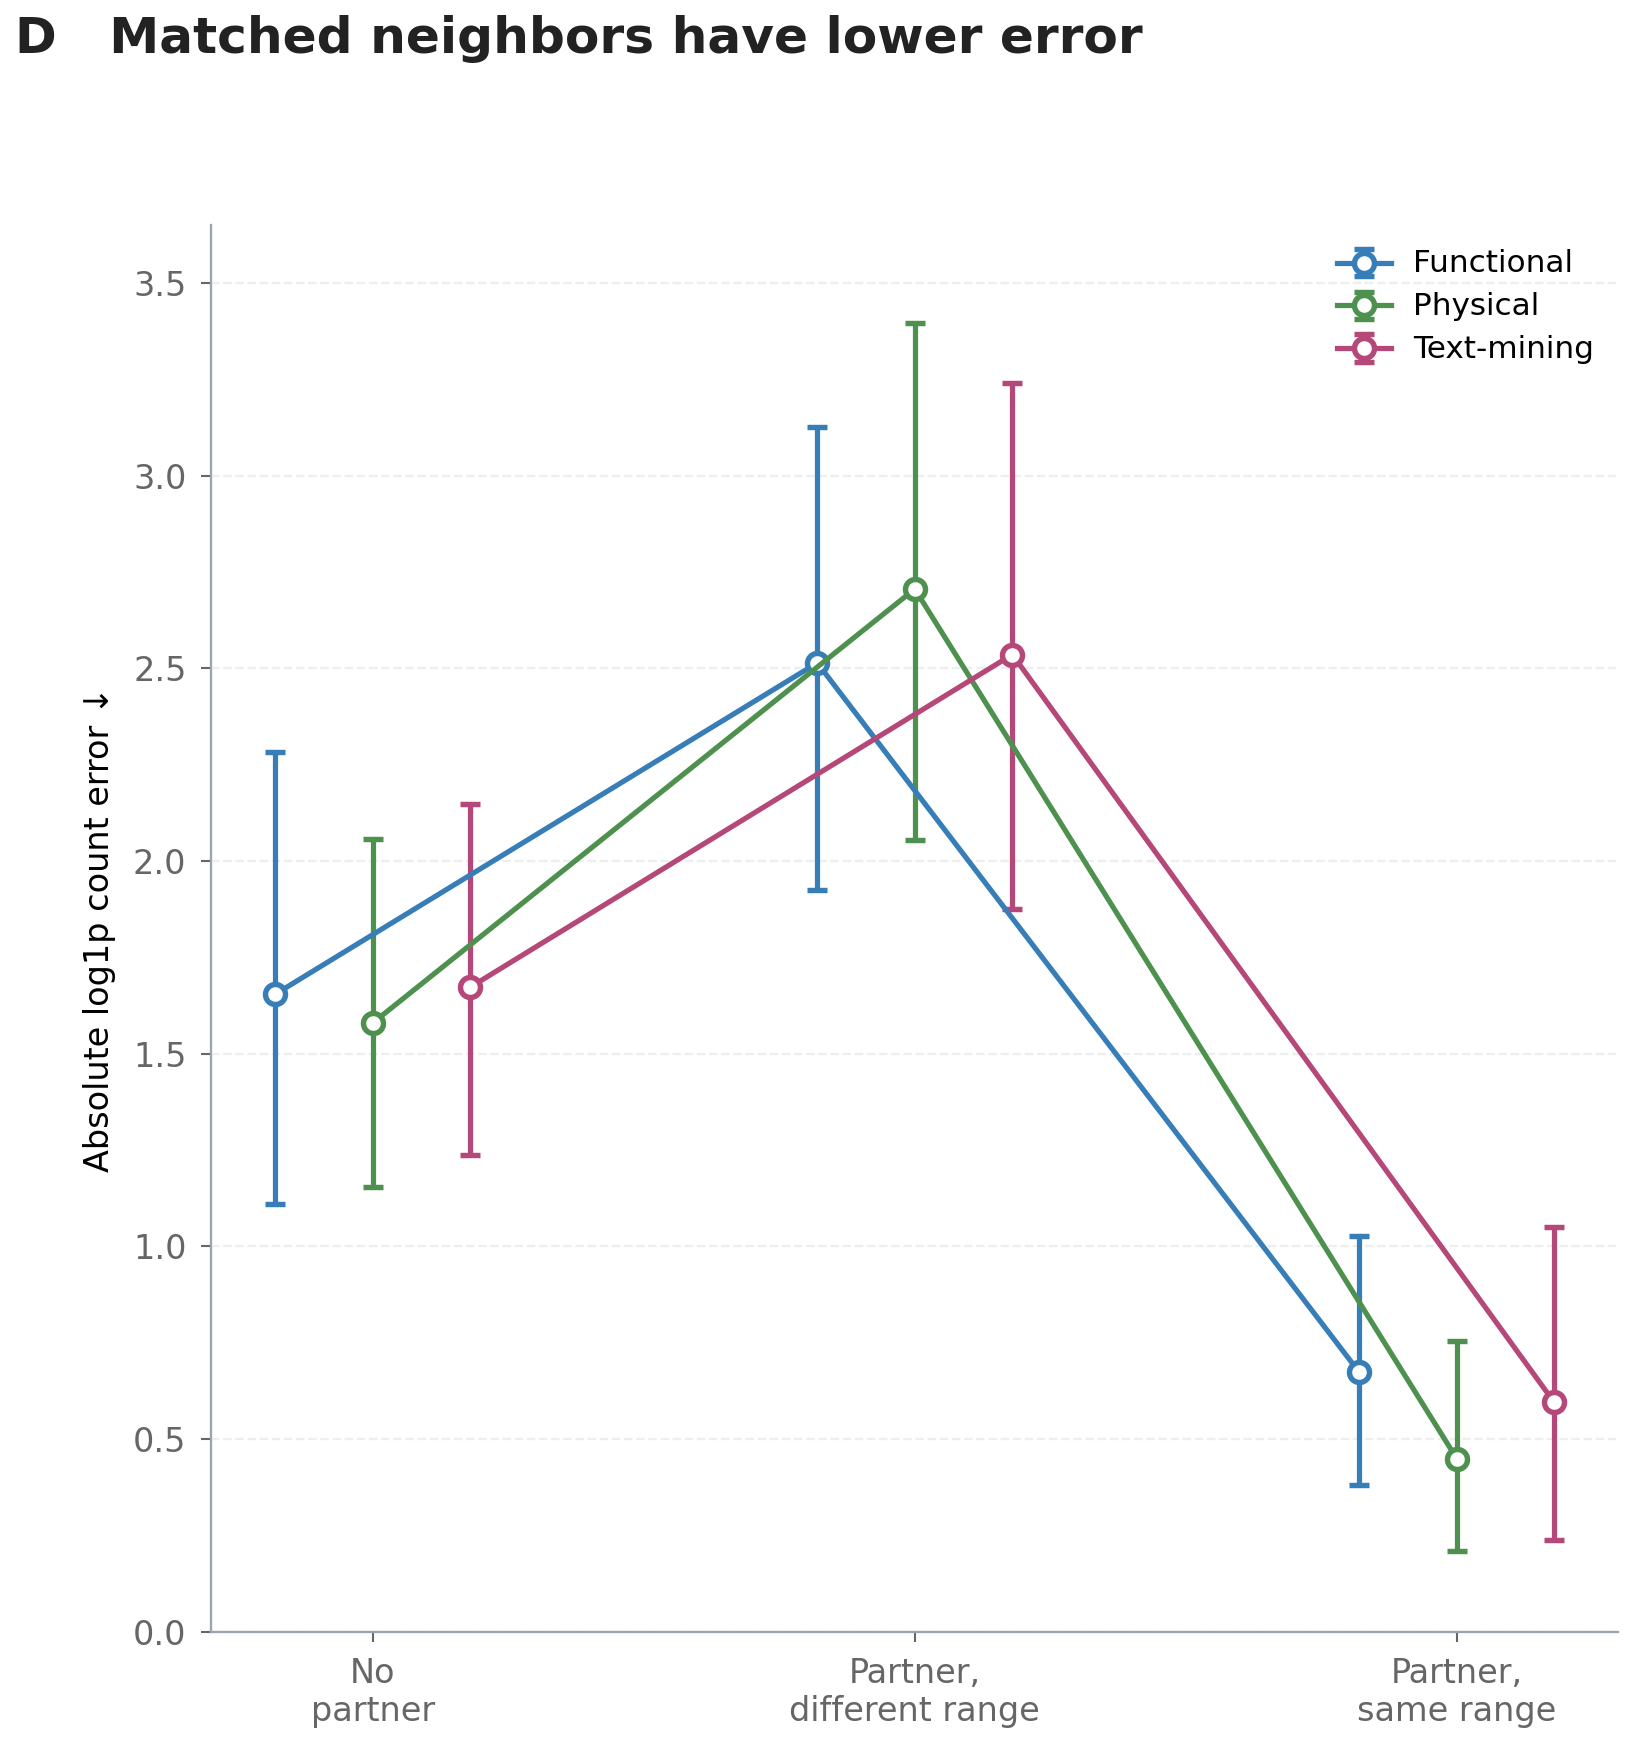

In [6]:
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading
_data = D_DATA[
    D_DATA["stratum"].eq("actual_nonzero")
    & D_DATA["outcome"].eq("bioagents_absolute_log1p_error")
]
_buckets = ("A", "B", "C")
_bucket_labels = ("No\npartner", "Partner,\ndifferent range", "Partner,\nsame range")

# ------------------------------------------------------------------ D
def draw_d(container):
    _heading(container, "D", "Matched neighbors have lower error")
    ax = container.subplots()
    _offsets = {"functional": -0.18, "physical": 0.0, "literature": 0.18}
    for _network in NETWORK_COLORS:
        _selected = _data[_data["network"].eq(_network)].set_index("bucket").loc[list(_buckets)]
        _x = np.arange(len(_buckets), dtype=float) + _offsets[_network]
        _mean = _selected["mean"].to_numpy(dtype=float)
        _low = _selected["mean_ci_low"].to_numpy(dtype=float)
        _high = _selected["mean_ci_high"].to_numpy(dtype=float)
        ax.errorbar(
            _x,
            _mean,
            yerr=np.vstack((_mean - _low, _high - _mean)),
            color=NETWORK_COLORS[_network],
            marker="o",
            markersize=4.8,
            markerfacecolor="white",
            markeredgewidth=1.3,
            linewidth=1.25,
            capsize=2.5,
            label=NETWORK_LABELS[_network],
            zorder=3,
        )
    ax.set_xticks(np.arange(len(_buckets)), _bucket_labels)
    ax.set_ylabel("Absolute log1p count error ↓")
    ax.set_ylim(0, 3.65)
    ax.legend(frameon=False, loc="upper right", fontsize=6.5)
    _clean_axis(ax, "y")
    ax.set_box_aspect(1)

fig_d, outputs_d = save_panel("D", draw_d, (4.2, 4.2))
fig_d;

## Figure 3E

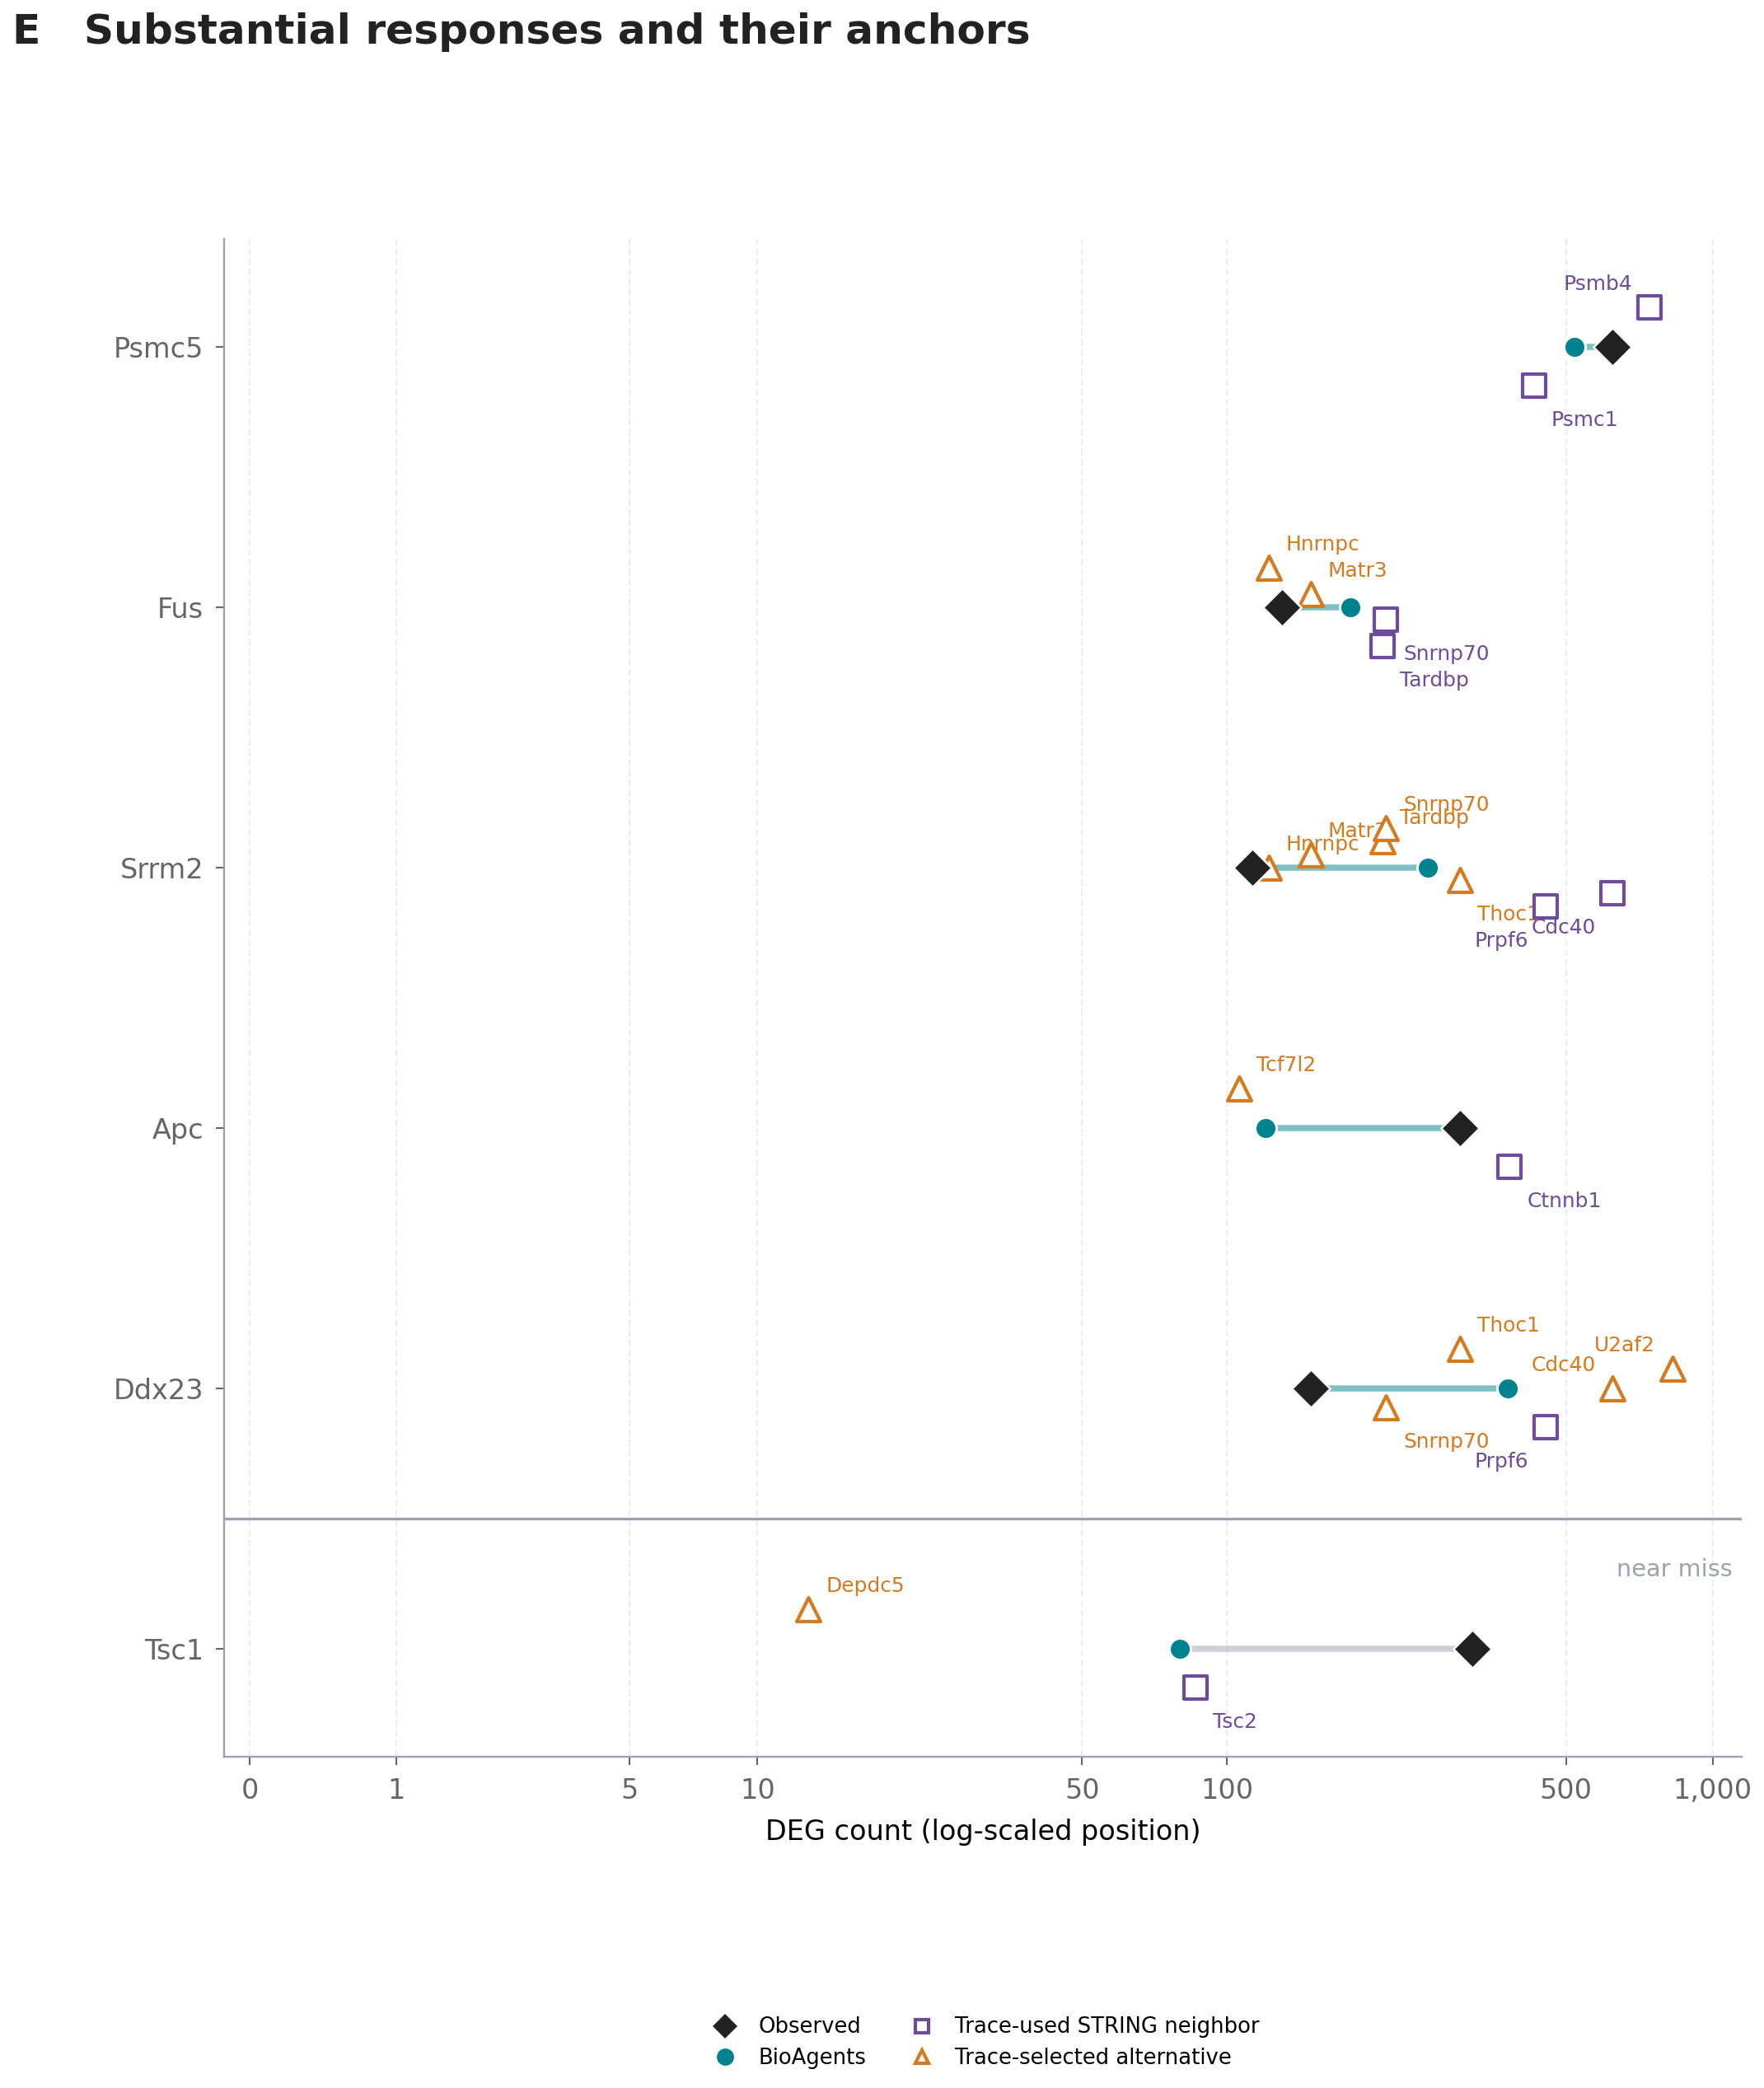

In [7]:
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading
_cases = E_CASES.copy()
_anchors = E_ANCHORS.copy()
_string_color = "#6f4c9b"
_alternative_color = "#d57a1f"

# ------------------------------------------------------------------ E
def draw_e(container):
    _heading(container, "E", "Substantial responses and their anchors")
    ax = container.subplots()
    _n = len(_cases)
    for _index, _case in enumerate(_cases.itertuples(index=False)):
        _y = float(_n - 1 - _index)
        _actual_x = np.log1p(float(_case.actual_n_degs))
        _predicted_x = np.log1p(float(_case.bioagents_predicted_n_degs))
        _line_color = _CHROME["axis"] if _case.set == "near_miss" else _CHROME["bioagents"]
        ax.plot(
            [_actual_x, _predicted_x],
            [_y, _y],
            color=_line_color,
            alpha=0.50,
            linewidth=1.8,
            zorder=1,
        )
        _case_anchors = _anchors[_anchors["target_name"].eq(_case.target_name)]
        _jitters = np.linspace(-0.15, 0.15, len(_case_anchors)) if len(_case_anchors) > 1 else np.array([0.0])
        for _anchor, _jitter in zip(_case_anchors.itertuples(index=False), _jitters):
            _is_string = _anchor.anchor_source == "trace_used_string"
            _color = _string_color if _is_string else _alternative_color
            _marker = "s" if _is_string else "^"
            _x = np.log1p(float(_anchor.anchor_n_degs))
            ax.scatter(
                [_x],
                [_y + _jitter],
                s=48,
                marker=_marker,
                facecolor="white",
                edgecolor=_color,
                linewidth=1.0,
                clip_on=False,
                zorder=4,
            )
            _right = float(_anchor.anchor_n_degs) < 450
            ax.annotate(
                _anchor.anchor_name,
                (_x, _y + _jitter),
                xytext=(5 if _right else -5, 4 if _jitter >= 0 else -7),
                textcoords="offset points",
                ha="left" if _right else "right",
                va="bottom" if _jitter >= 0 else "top",
                fontsize=5.2,
                color=_color,
            )
        ax.scatter(
            [_actual_x],
            [_y],
            s=62,
            marker="D",
            facecolor=_CHROME["ink"],
            edgecolor="white",
            linewidth=0.6,
            clip_on=False,
            zorder=6,
        )
        ax.scatter(
            [_predicted_x],
            [_y],
            s=39,
            marker="o",
            facecolor=_CHROME["bioagents"],
            edgecolor="white",
            linewidth=0.7,
            clip_on=False,
            zorder=7,
        )
    _tick_values = np.asarray((0, 1, 5, 10, 50, 100, 500, 1000), dtype=float)
    ax.set_xticks(np.log1p(_tick_values), [f"{int(value):,}" for value in _tick_values])
    ax.set_xlim(-0.12, np.log1p(1150))
    ax.set_yticks(
        np.arange(_n - 1, -1, -1),
        _cases["target_name"].tolist(),
    )
    ax.axhline(0.5, color=_CHROME["axis"], linewidth=0.8)
    ax.text(
        np.log1p(1100),
        0.35,
        "near miss",
        ha="right",
        va="top",
        fontsize=6.0,
        color=_CHROME["axis"],
    )
    ax.set_xlabel("DEG count (log-scaled position)")
    _clean_axis(ax, "x")
    ax.set_box_aspect(1)
    ax.legend(
        handles=[
            Line2D([], [], marker="D", linestyle="", color=_CHROME["ink"], label="Observed"),
            Line2D([], [], marker="o", linestyle="", color=_CHROME["bioagents"], label="BioAgents"),
            Line2D([], [], marker="s", linestyle="", markerfacecolor="white", color=_string_color, label="Trace-used STRING neighbor"),
            Line2D([], [], marker="^", linestyle="", markerfacecolor="white", color=_alternative_color, label="Trace-selected alternative"),
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.16),
        ncol=2,
        frameon=False,
        fontsize=5.4,
    )

fig_e, outputs_e = save_panel("E", draw_e, (5.5, 5.5))
fig_e;

## Figure 3G

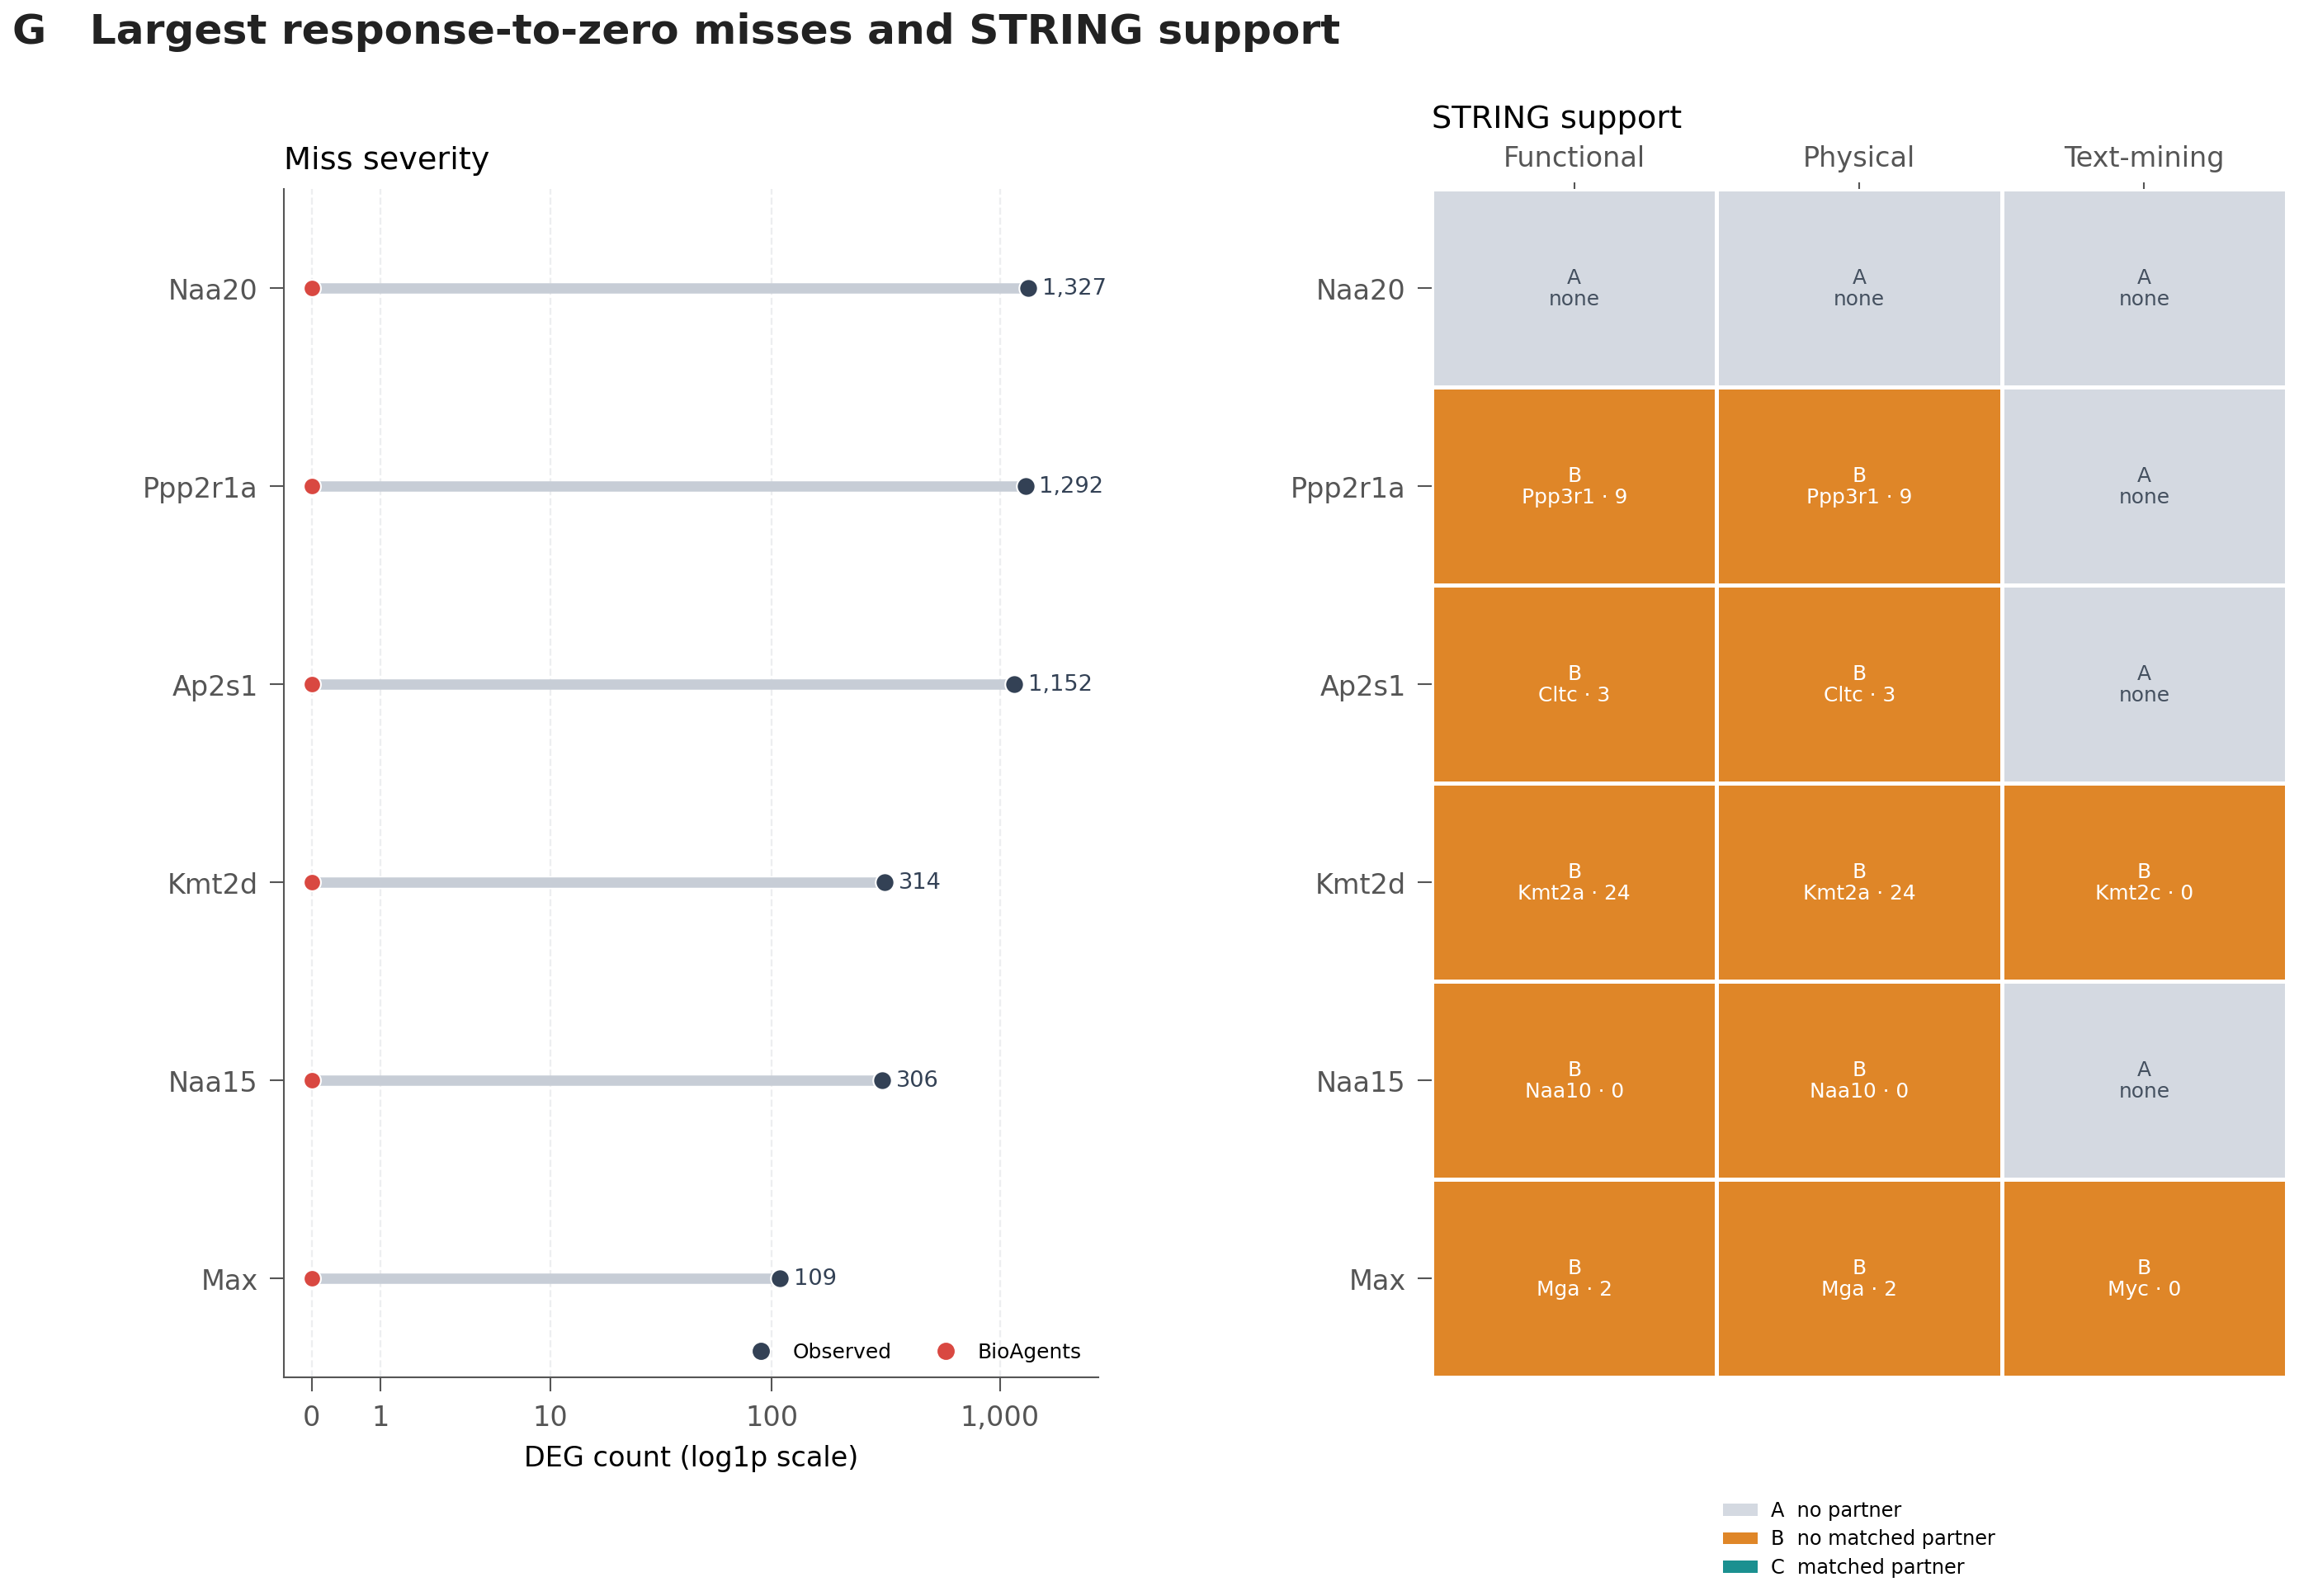

In [8]:
_CHROME = CHROME
_heading = heading
_data = G_DATA.copy()
_target_order = list(pd.unique(_data["target_order"]))
_network_order = ("functional", "physical", "literature")
_bucket_colors = {"A": "#d4d9e1", "B": "#df8628", "C": "#1b9090"}
_bucket_labels = {
    "A": "A  no partner",
    "B": "B  no matched partner",
    "C": "C  matched partner",
}
_targets = (
    _data.groupby("target_order", sort=False)
    .agg(
        actual_n_degs=("actual_n_degs", "first"),
        bioagents_predicted_n_degs=("bioagents_predicted_n_degs", "first"),
    )
    .reindex(_target_order)
    .reset_index()
)

# ------------------------------------------------------------------ G
def draw_g(container):
    _heading(container, "G", "Largest response-to-zero misses and STRING support")
    _grid = container.add_gridspec(1, 2, width_ratios=(1.0, 1.05), wspace=0.40)
    _severity = container.add_subplot(_grid[0, 0])
    _matrix = container.add_subplot(_grid[0, 1])
    _y = np.arange(len(_targets))
    _observed_x = np.log1p(_targets["actual_n_degs"].to_numpy(dtype=float))
    _predicted_x = np.log1p(_targets["bioagents_predicted_n_degs"].to_numpy(dtype=float))
    _severity.hlines(_y, _predicted_x, _observed_x, color=_CHROME["link"], linewidth=3.0)
    _severity.scatter(_observed_x, _y, s=29, color="#334155", edgecolor="white", linewidth=0.5, zorder=3)
    _severity.scatter(_predicted_x, _y, s=25, color=_CHROME["error"], edgecolor="white", linewidth=0.5, zorder=3)
    for _x, _yy, _value in zip(_observed_x, _y, _targets["actual_n_degs"]):
        _severity.annotate(f"{int(_value):,}", (_x, _yy), xytext=(4, 0), textcoords="offset points", va="center", fontsize=5.7, color="#334155")
    _tick_values = np.asarray((0, 1, 10, 100, 1000), dtype=float)
    _severity.set_xticks(np.log1p(_tick_values), ["0", "1", "10", "100", "1,000"])
    _severity.set_xlim(-0.28, max(_observed_x) + 0.70)
    _severity.set_yticks(_y, _target_order)
    _severity.set_ylim(len(_targets) - 0.5, -0.5)
    _severity.set_xlabel("DEG count (log1p scale)")
    _severity.set_title("Miss severity", loc="left", fontsize=8.0)
    _severity.grid(axis="x", color=_CHROME["grid"], linewidth=0.55)
    _severity.spines[["top", "right"]].set_visible(False)
    _severity.legend(
        handles=[
            Line2D([], [], marker="o", linestyle="", color="#334155", label="Observed"),
            Line2D([], [], marker="o", linestyle="", color=_CHROME["error"], label="BioAgents"),
        ],
        loc="lower right",
        frameon=False,
        fontsize=5.2,
        ncol=2,
    )

    _lookup = _data.set_index(["target_order", "network"])
    for _row, _target in enumerate(_target_order):
        for _column, _network in enumerate(_network_order):
            _record = _lookup.loc[(_target, _network)]
            _bucket = str(_record["bucket"])
            _matrix.add_patch(
                Rectangle(
                    (_column - 0.5, _row - 0.5),
                    1,
                    1,
                    facecolor=_bucket_colors[_bucket],
                    edgecolor="white",
                    linewidth=1.2,
                )
            )
            if _bucket == "A":
                _text, _text_color = "A\nnone", "#44505f"
            else:
                _partner = str(_record["best_partner"])
                _partner_count = int(float(_record["best_partner_n_degs"]))
                _text, _text_color = f"{_bucket}\n{_partner} · {_partner_count:,}", "white"
            _matrix.text(_column, _row, _text, ha="center", va="center", fontsize=5.2, color=_text_color, linespacing=1.1)
    _matrix.set_xticks(np.arange(3), [NETWORK_LABELS[key] for key in _network_order])
    _matrix.xaxis.tick_top()
    _matrix.tick_params(axis="x", length=2, pad=3)
    _matrix.set_yticks(np.arange(len(_target_order)), _target_order)
    _matrix.set_xlim(-0.5, 2.5)
    _matrix.set_ylim(len(_target_order) - 0.5, -0.5)
    _matrix.set_title("STRING support", loc="left", fontsize=8.0, pad=18)
    for _spine in _matrix.spines.values():
        _spine.set_visible(False)
    _matrix.legend(
        handles=[Patch(facecolor=_bucket_colors[key], edgecolor="none", label=_bucket_labels[key]) for key in ("A", "B", "C")],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.09),
        frameon=False,
        fontsize=5.0,
        ncol=1,
    )
    # G is intentionally wide: it is a paired severity/matrix comparison.

fig_g, outputs_g = save_panel("G", draw_g, (7.2, 4.3))
fig_g;

## Figure 3H

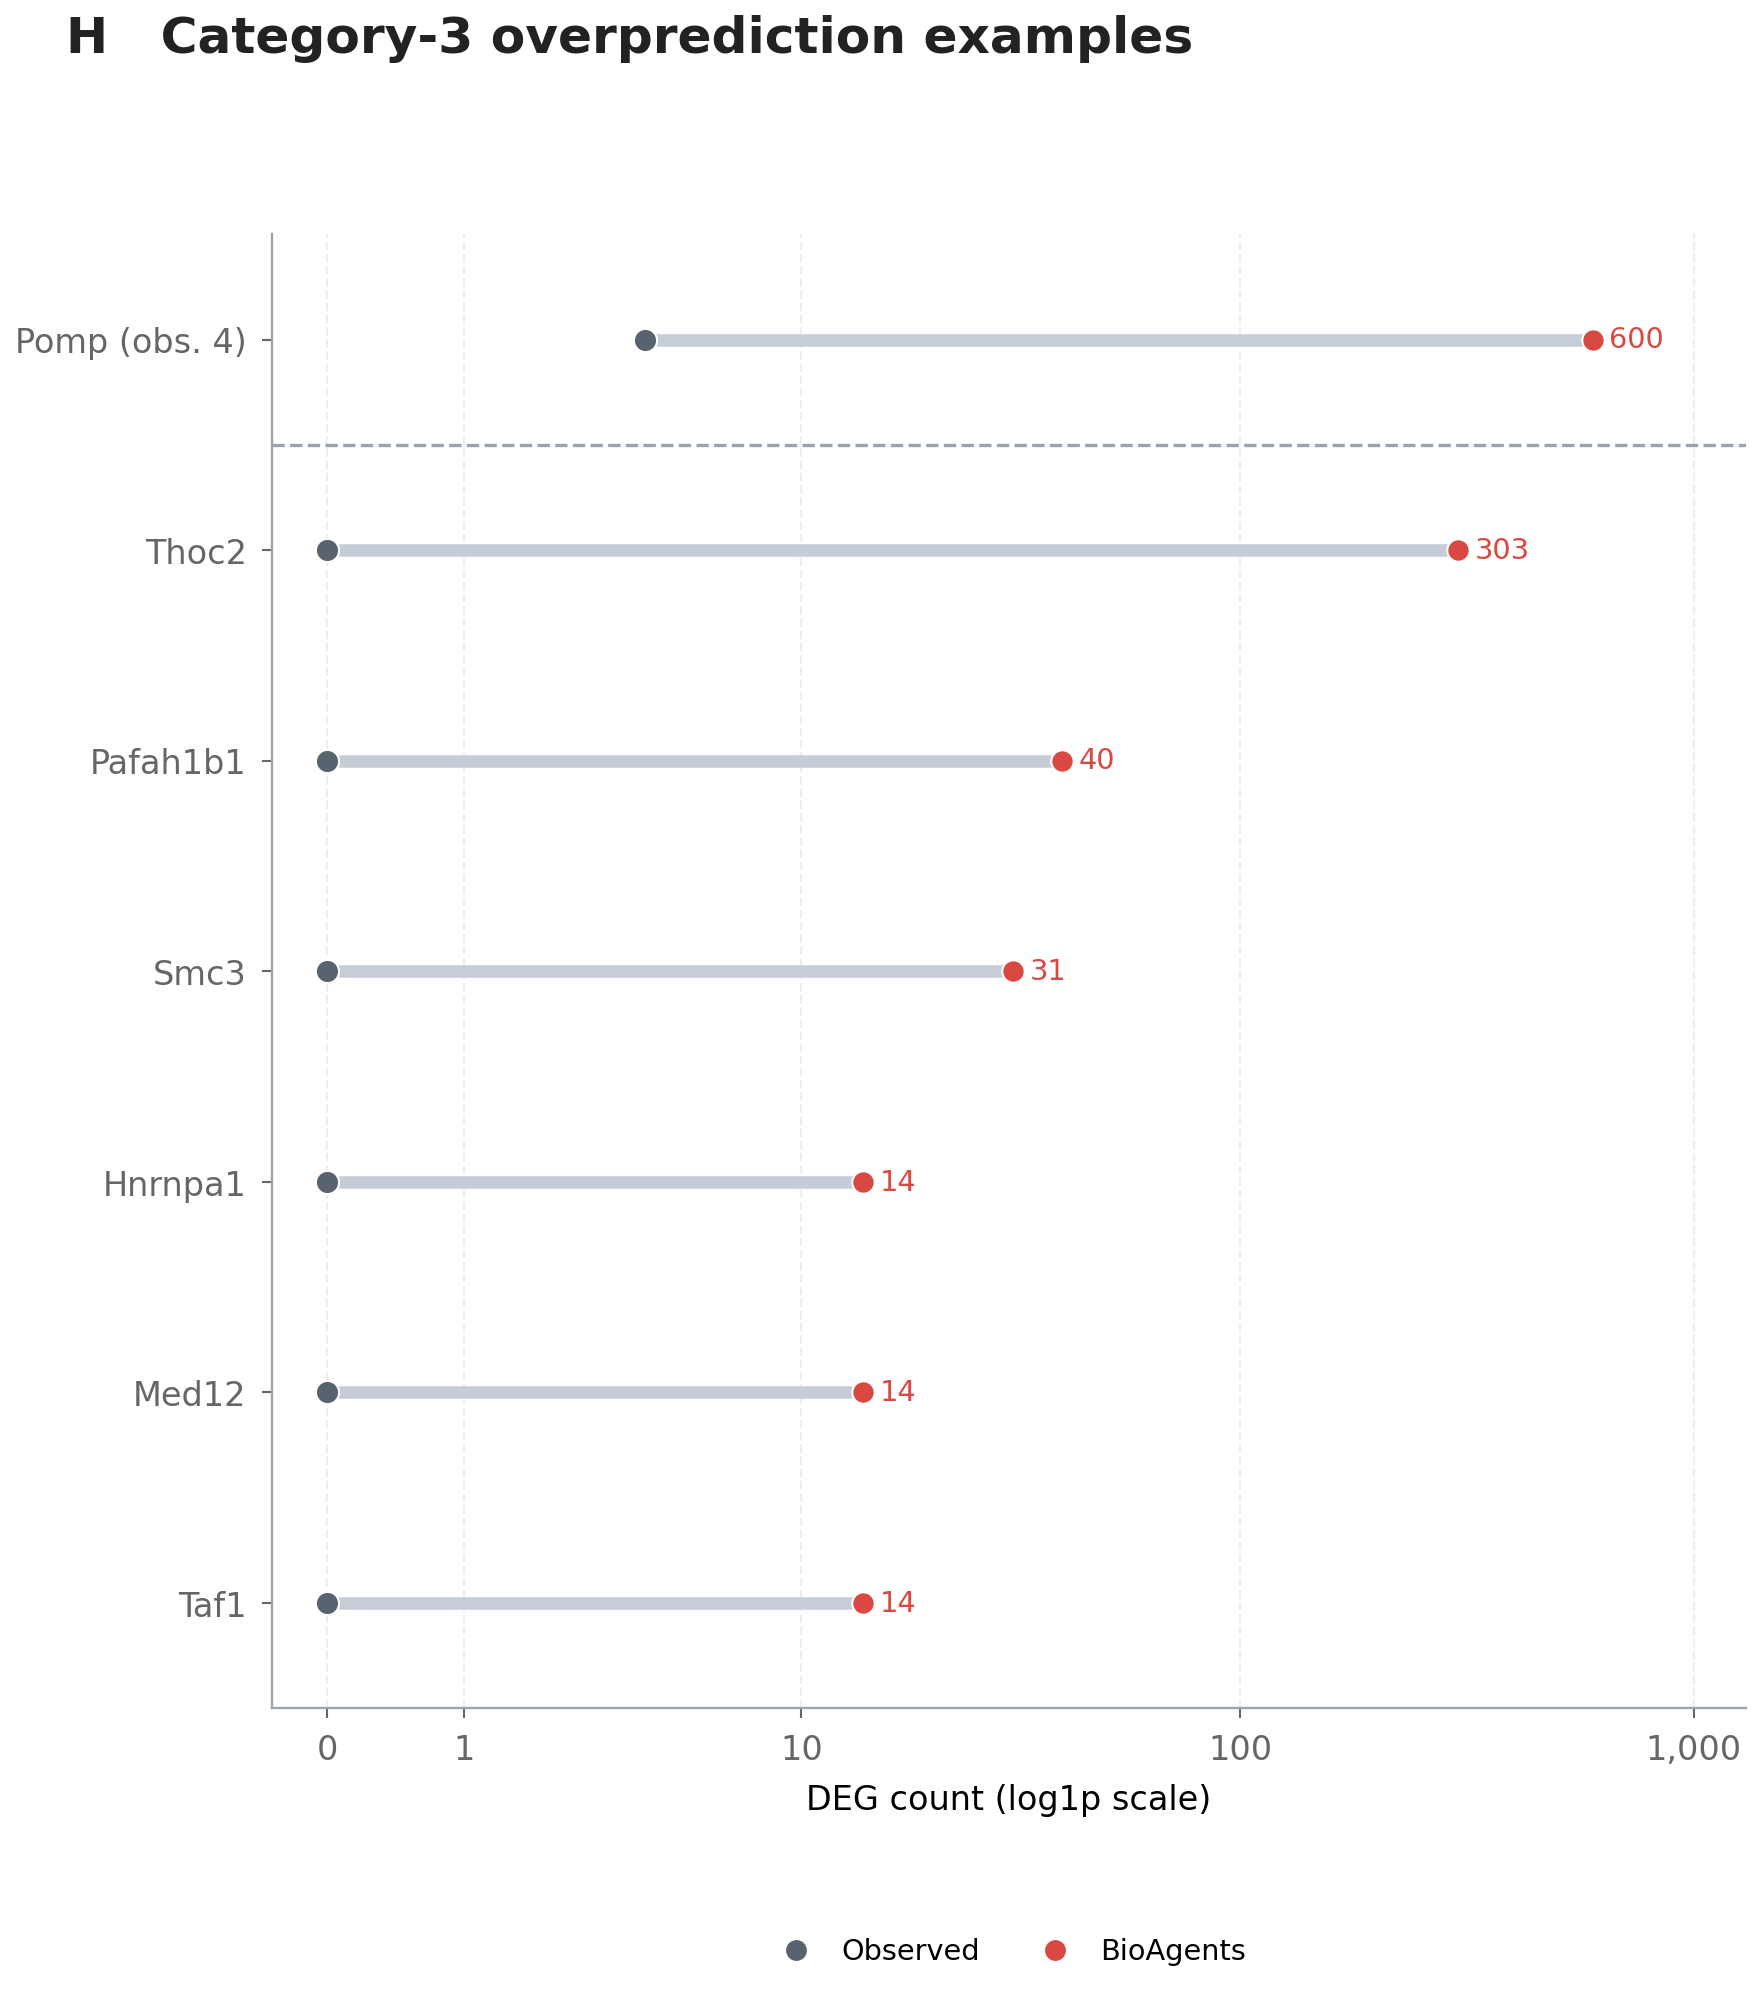

In [9]:
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading
_data = H_DATA.copy()

# ------------------------------------------------------------------ H
def draw_h(container):
    _heading(container, "H", "Category-3 overprediction examples")
    ax = container.subplots()
    _y = np.arange(len(_data))
    _observed_x = np.log1p(_data["actual_n_degs"].to_numpy(dtype=float))
    _predicted_x = np.log1p(_data["bioagents_predicted_n_degs"].to_numpy(dtype=float))
    ax.hlines(_y, _observed_x, _predicted_x, color=_CHROME["link"], linewidth=3.0)
    ax.scatter(_observed_x, _y, s=31, color=_CHROME["observed"], edgecolor="white", linewidth=0.5, zorder=3)
    ax.scatter(_predicted_x, _y, s=29, color=_CHROME["error"], edgecolor="white", linewidth=0.5, zorder=3)
    for _x, _yy, _value in zip(_predicted_x, _y, _data["bioagents_predicted_n_degs"]):
        ax.annotate(f"{int(_value):,}", (_x, _yy), xytext=(4, 0), textcoords="offset points", va="center", fontsize=6.0, color=_CHROME["error"])
    _tick_values = np.asarray((0, 1, 10, 100, 1000), dtype=float)
    ax.set_xticks(np.log1p(_tick_values), ["0", "1", "10", "100", "1,000"])
    ax.set_xlim(-0.28, np.log1p(1300))
    ax.set_yticks(_y, _data["display_name"])
    ax.set_ylim(len(_data) - 0.5, -0.5)
    ax.axhline(0.5, color=_CHROME["axis"], linestyle="--", linewidth=0.8)
    ax.set_xlabel("DEG count (log1p scale)")
    _clean_axis(ax, "x")
    ax.set_box_aspect(1)
    ax.legend(
        handles=[
            Line2D([], [], marker="o", linestyle="", color=_CHROME["observed"], label="Observed"),
            Line2D([], [], marker="o", linestyle="", color=_CHROME["error"], label="BioAgents"),
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.14),
        frameon=False,
        fontsize=6.0,
        ncol=2,
    )

fig_h, outputs_h = save_panel("H", draw_h, (4.4, 4.4))
fig_h;

## Figure 3I

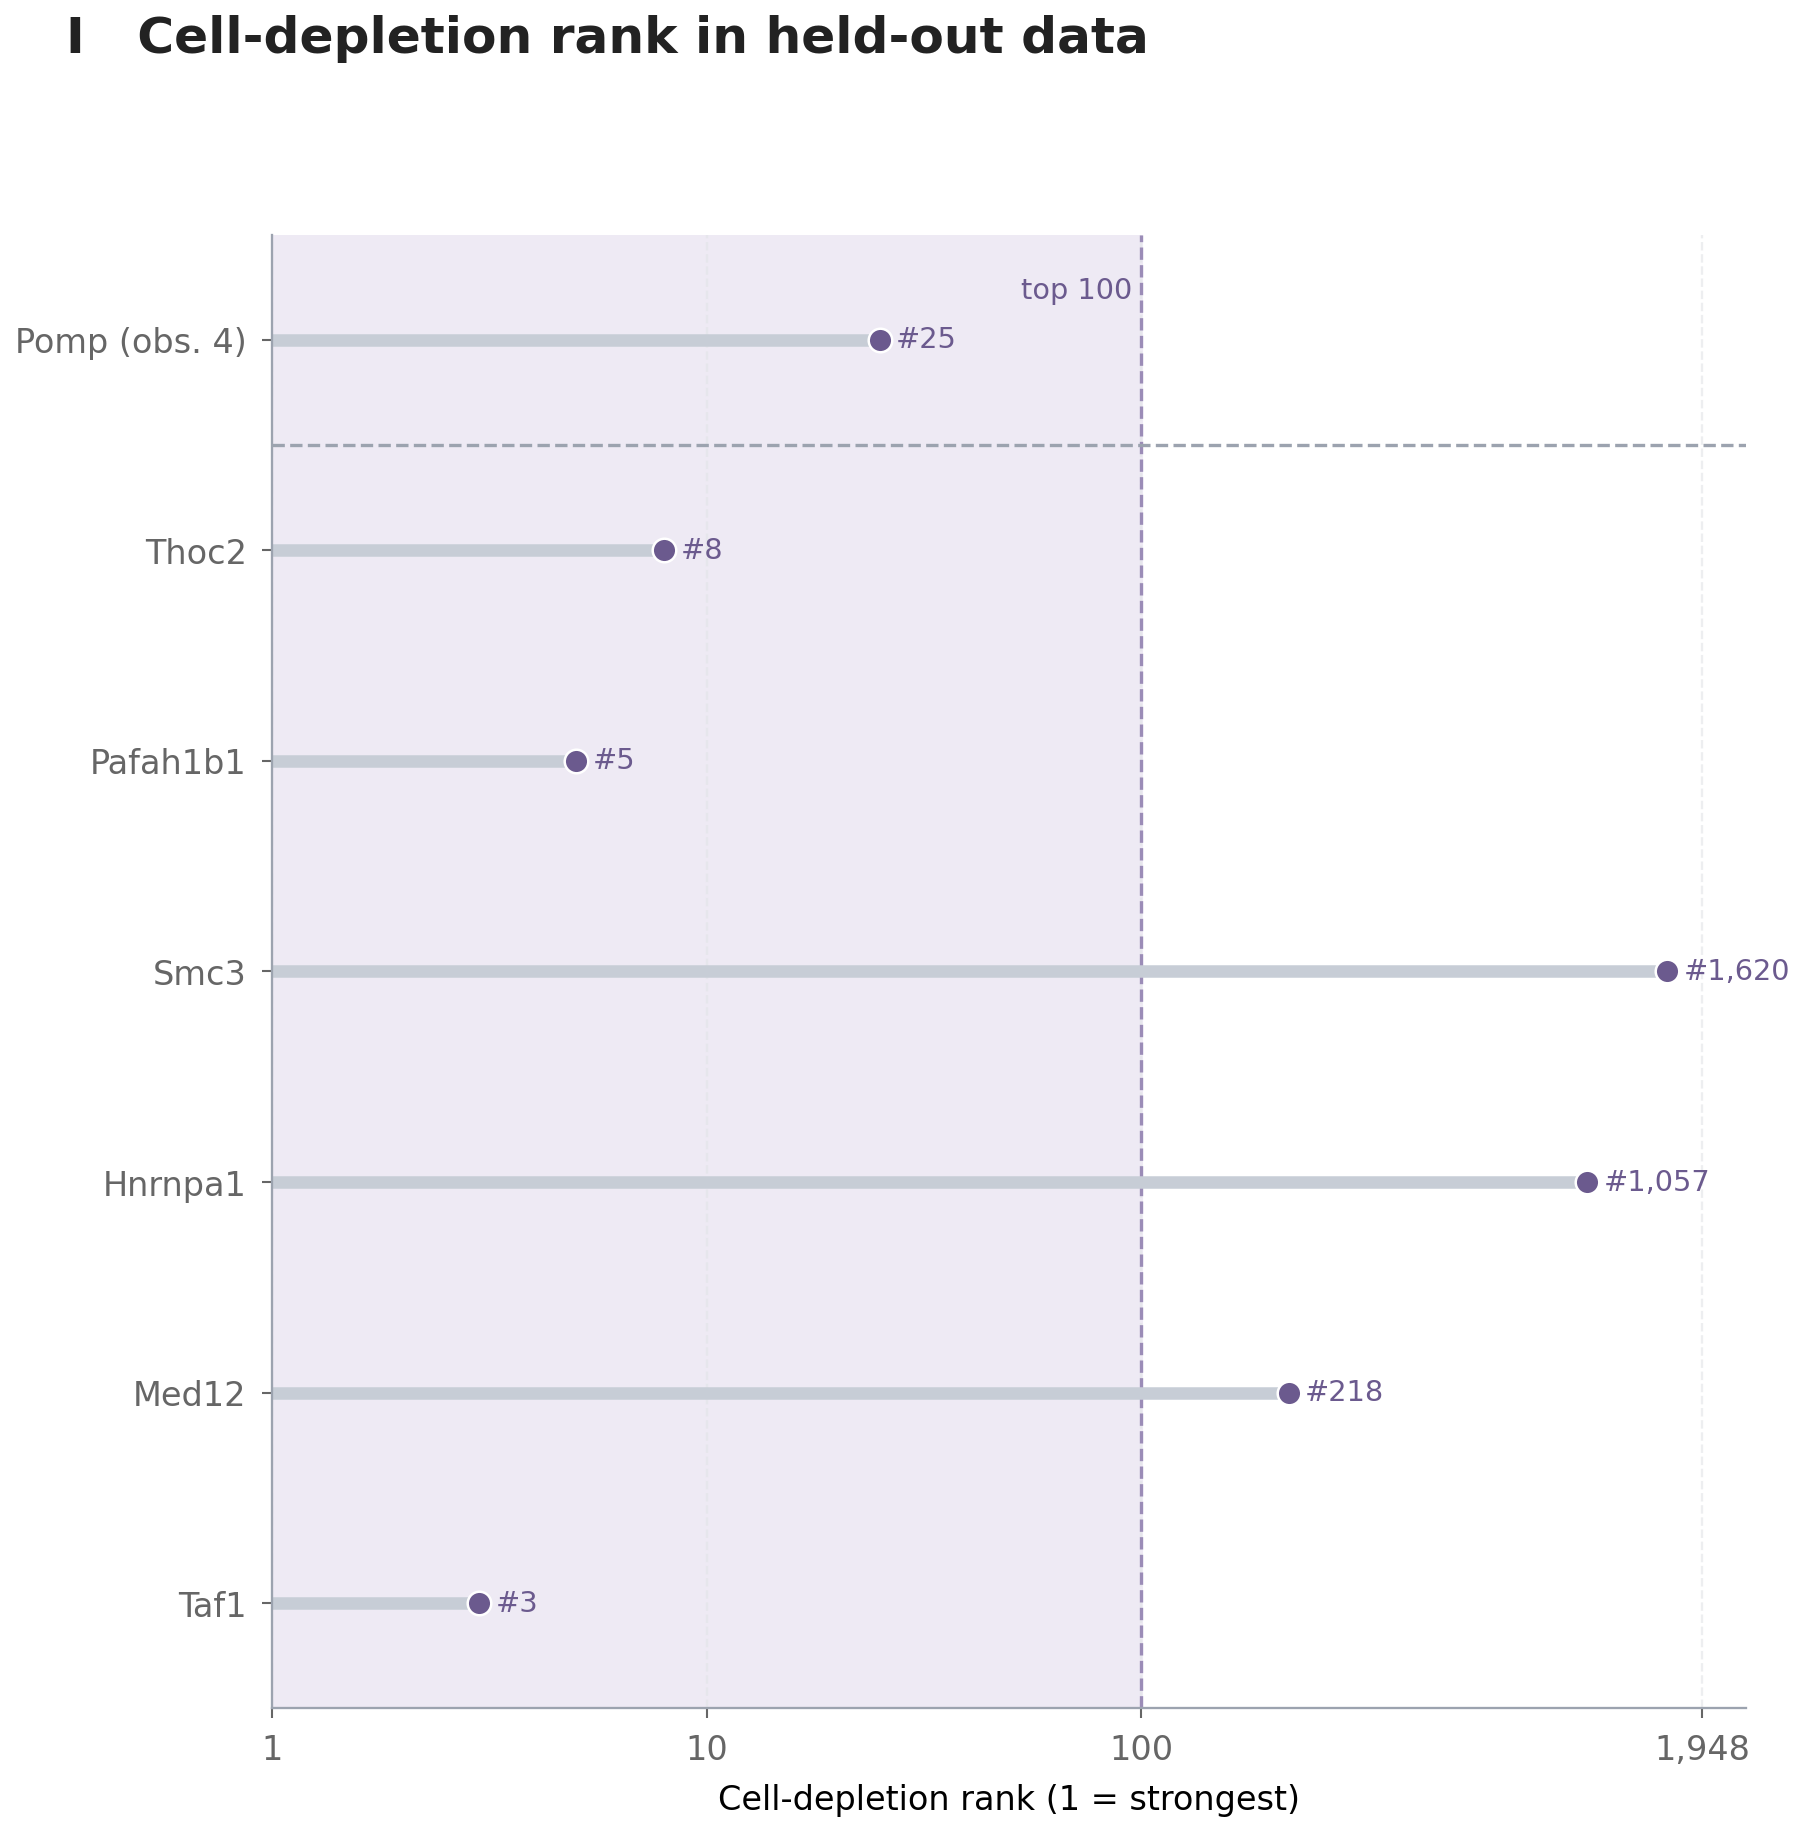

In [10]:
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading
_data = H_DATA.copy()

# ------------------------------------------------------------------ I
def draw_i(container):
    _heading(container, "I", "Cell-depletion rank in held-out data")
    ax = container.subplots()
    _y = np.arange(len(_data))
    _rank = _data["depletion_rank"].to_numpy(dtype=float)
    _x = np.log10(_rank)
    ax.axvspan(0, 2, color="#eeeaf4", zorder=0)
    ax.axvline(2, color="#9b8cb7", linestyle="--", linewidth=0.8)
    ax.hlines(_y, 0, _x, color=_CHROME["link"], linewidth=3.0)
    ax.scatter(_x, _y, s=32, color=_CHROME["purple"], edgecolor="white", linewidth=0.6, zorder=3)
    for _xx, _yy, _value in zip(_x, _y, _rank):
        ax.annotate(f"#{int(_value):,}", (_xx, _yy), xytext=(4, 0), textcoords="offset points", va="center", fontsize=6.0, color=_CHROME["purple"])
    ax.set_xticks(np.log10([1, 10, 100, 1948]), ["1", "10", "100", "1,948"])
    ax.set_xlim(0, np.log10(1948) + 0.10)
    ax.set_yticks(_y, _data["display_name"])
    ax.set_ylim(len(_data) - 0.5, -0.5)
    ax.axhline(0.5, color=_CHROME["axis"], linestyle="--", linewidth=0.8)
    ax.text(1.98, -0.30, "top 100", ha="right", va="top", fontsize=6.0, color=_CHROME["purple"])
    ax.set_xlabel("Cell-depletion rank (1 = strongest)")
    _clean_axis(ax, "x")
    ax.set_box_aspect(1)

fig_i, outputs_i = save_panel("I", draw_i, (4.4, 4.4))
fig_i;

## Figure 3J

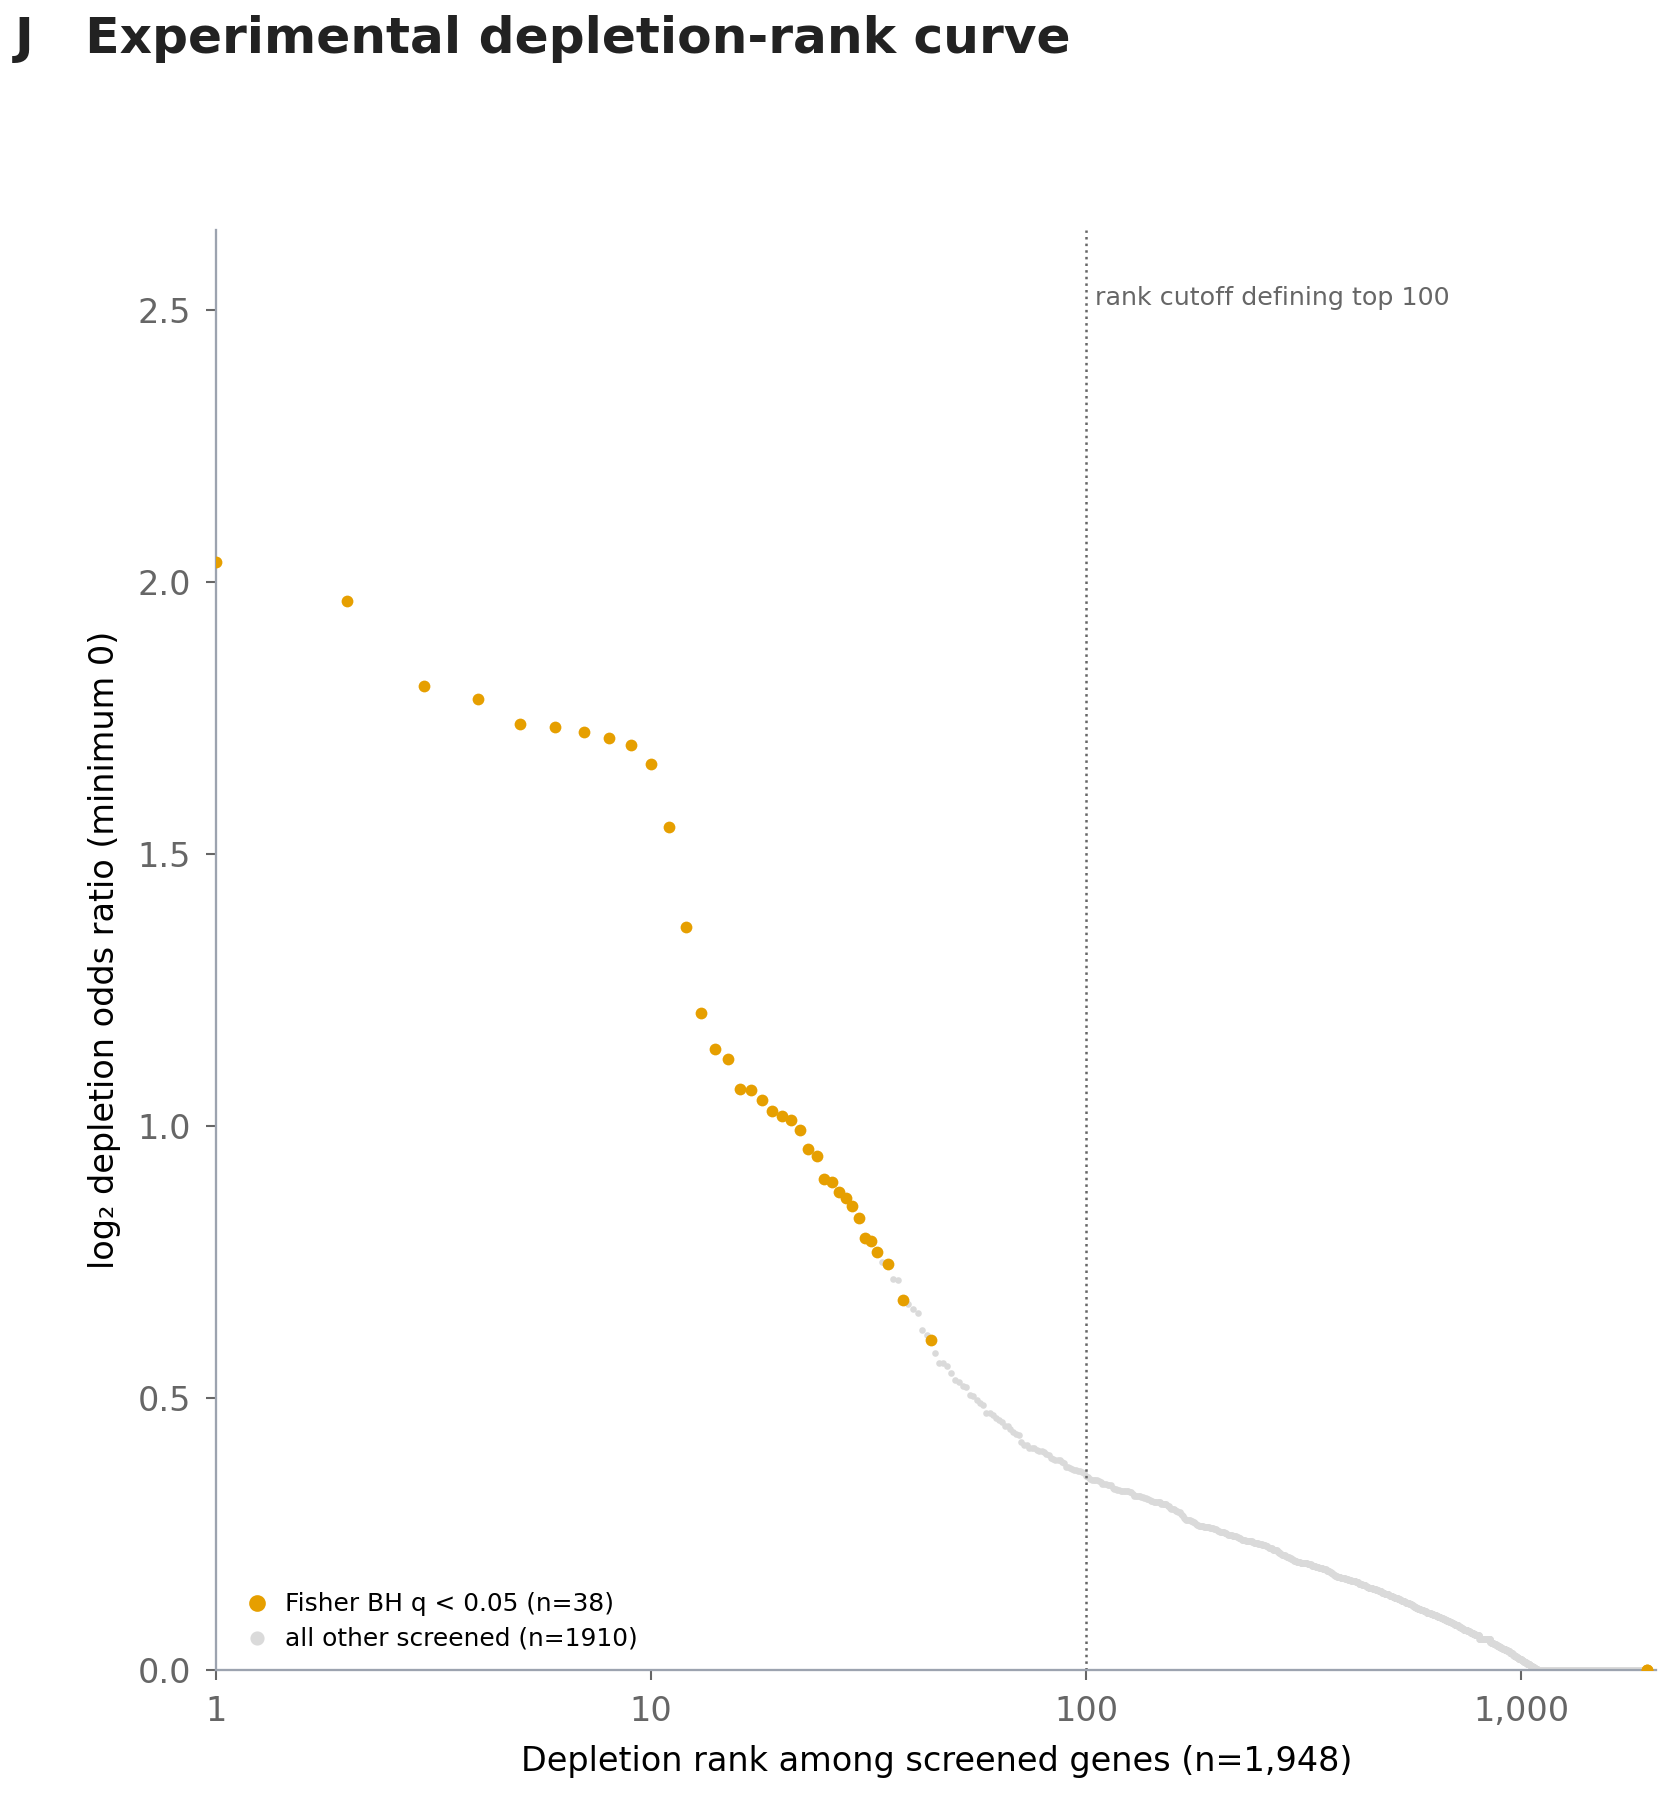

In [11]:
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading
_ranking = J_DATA.copy()

# ------------------------------------------------------------------ J
def draw_j(container):
    _heading(container, "J", "Experimental depletion-rank curve")
    ax = container.subplots()
    _other = _ranking[~_ranking["significant"]]
    _significant = _ranking[_ranking["significant"]]
    ax.scatter(
        np.log10(_other["rank"]),
        _other["depletion_log2_or"],
        s=2.5,
        color="#dadada",
        linewidth=0,
        rasterized=True,
        zorder=2,
    )
    ax.scatter(
        np.log10(_significant["rank"]),
        _significant["depletion_log2_or"],
        s=8,
        color=_CHROME["orange"],
        linewidth=0,
        zorder=3,
    )
    _n = len(_ranking)
    _ymax = float(_ranking["depletion_log2_or"].max())
    ax.axhline(0, color=_CHROME["muted"], linestyle="--", linewidth=0.6)
    ax.axvline(2, color=_CHROME["muted"], linestyle=":", linewidth=0.6)
    ax.text(2.02, _ymax * 1.25, "rank cutoff defining top 100", fontsize=5.3, color=_CHROME["muted"], va="top")
    ax.set_xticks(np.log10([1, 10, 100, 1000]), ["1", "10", "100", "1,000"])
    ax.set_xlim(0, np.log10(_n * 1.05))
    ax.set_ylim(0, _ymax * 1.30)
    ax.set_xlabel(f"Depletion rank among screened genes (n={_n:,})")
    ax.set_ylabel("log₂ depletion odds ratio (minimum 0)")
    _clean_axis(ax)
    ax.set_box_aspect(1)
    ax.legend(
        handles=[
            Line2D([], [], marker="o", linestyle="", markersize=3, color=_CHROME["orange"], label=f"Fisher BH q < 0.05 (n={len(_significant)})"),
            Line2D([], [], marker="o", linestyle="", markersize=2.4, color="#dadada", label=f"all other screened (n={len(_other)})"),
        ],
        loc="lower left",
        frameon=False,
        fontsize=5.2,
        handletextpad=0.3,
    )

fig_j, outputs_j = save_panel("J", draw_j, (4.3, 4.3))
fig_j;

## Figure 3K

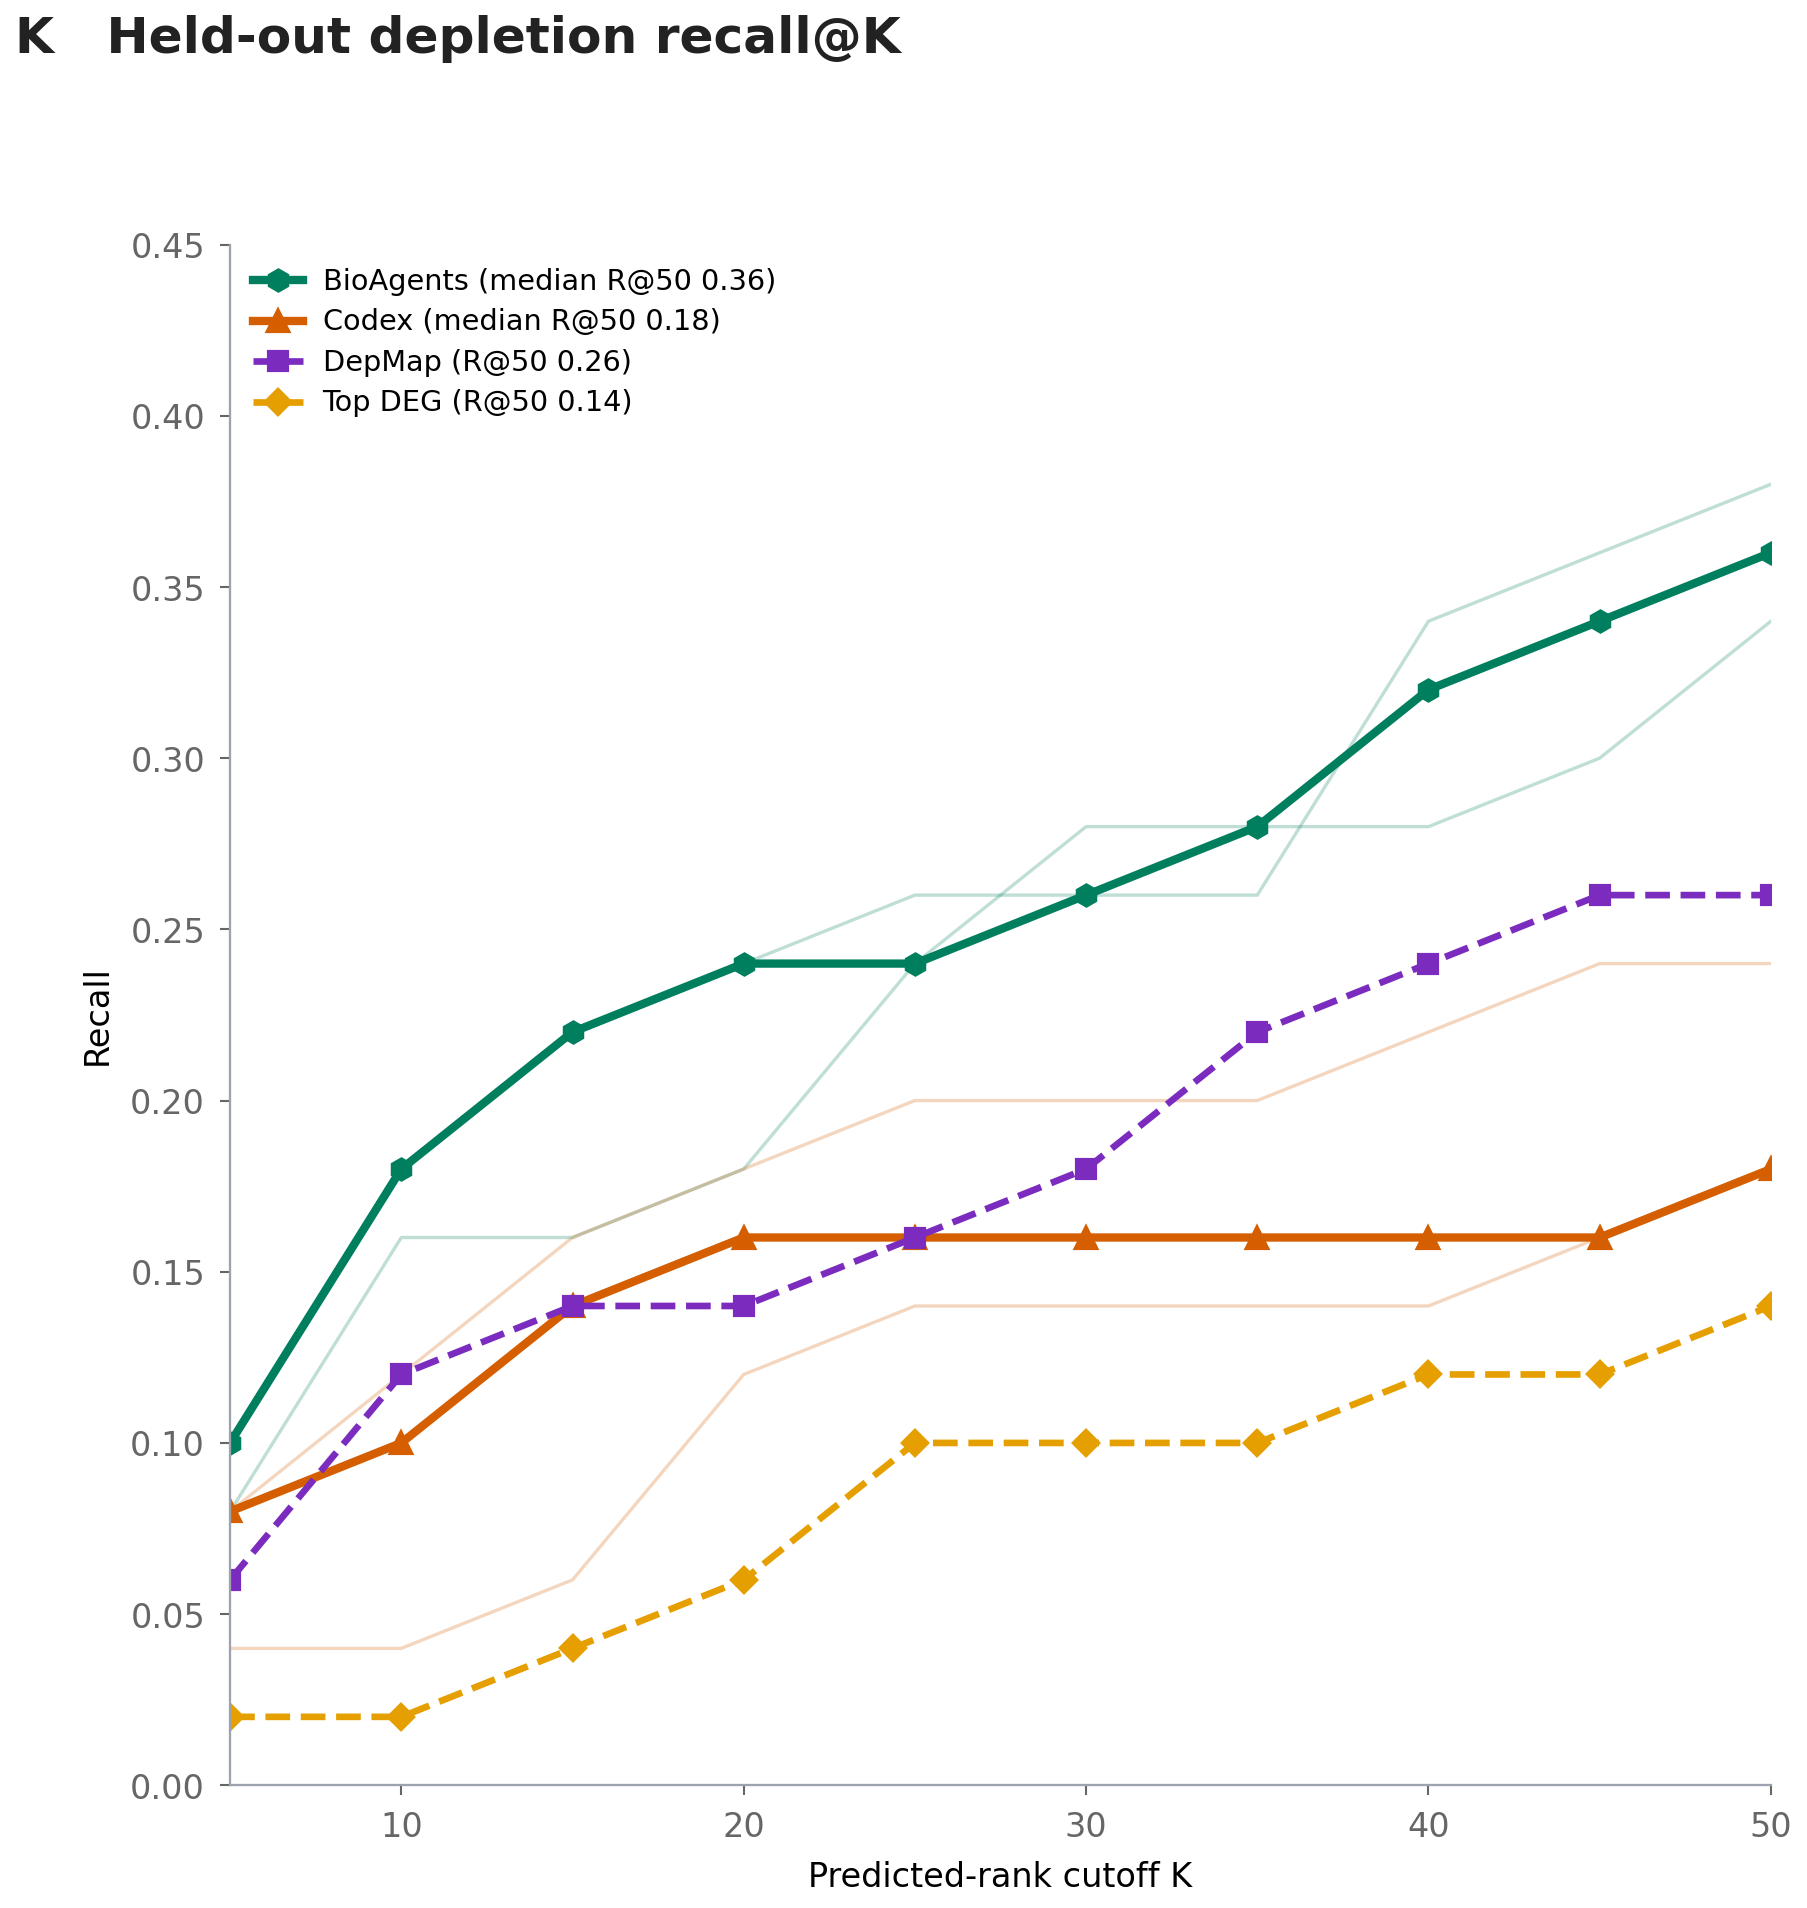

In [12]:
_clean_axis = clean_axis
_heading = heading
_data = K_DATA.copy()
_colors = {
    "BioAgents": "#007f5f",
    "Codex": "#d55e00",
    "DepMap": "#7b2cbf",
    "Top DEG": "#e69f00",
}
_markers = {"BioAgents": "h", "Codex": "^", "DepMap": "s", "Top DEG": "D"}
_baseline_methods = {"DepMap", "Top DEG"}

# ------------------------------------------------------------------ K
def draw_k(container):
    _heading(container, "K", "Held-out depletion recall@K")
    ax = container.subplots()
    for _cohort in ("BioAgents", "Codex", "DepMap", "Top DEG"):
        _selected = _data[_data["cohort"].eq(_cohort)]
        _is_baseline = _cohort in _baseline_methods
        if not _is_baseline:
            for _, _curve in _selected[_selected["series"].eq("individual")].groupby("replicate"):
                ax.plot(_curve["cutoff_k"], _curve["recall"], color=_colors[_cohort], linewidth=0.8, alpha=0.25)
            _curve = _selected[_selected["series"].eq("median")]
        else:
            _curve = _selected[_selected["series"].eq("baseline")]
        _terminal = float(_curve.loc[_curve["cutoff_k"].eq(50), "recall"].iloc[0])
        _terminal_label = "R@50" if _is_baseline else "median R@50"
        ax.plot(
            _curve["cutoff_k"],
            _curve["recall"],
            color=_colors[_cohort],
            linewidth=1.6 if _is_baseline else 2.0,
            linestyle="--" if _is_baseline else "-",
            marker=_markers[_cohort],
            markersize=4.2 if _is_baseline else 4.8,
            label=f"{_cohort} ({_terminal_label} {_terminal:.2f})",
        )
    ax.set_xlabel("Predicted-rank cutoff K")
    ax.set_ylabel("Recall")
    ax.set_xlim(5, 50)
    ax.set_ylim(0, 0.45)
    ax.set_xticks((10, 20, 30, 40, 50))
    ax.legend(frameon=False, loc="upper left", fontsize=6.0)
    _clean_axis(ax)
    ax.set_box_aspect(1)

fig_k, outputs_k = save_panel("K", draw_k, (4.6, 4.6))
fig_k;

## Figure 3L

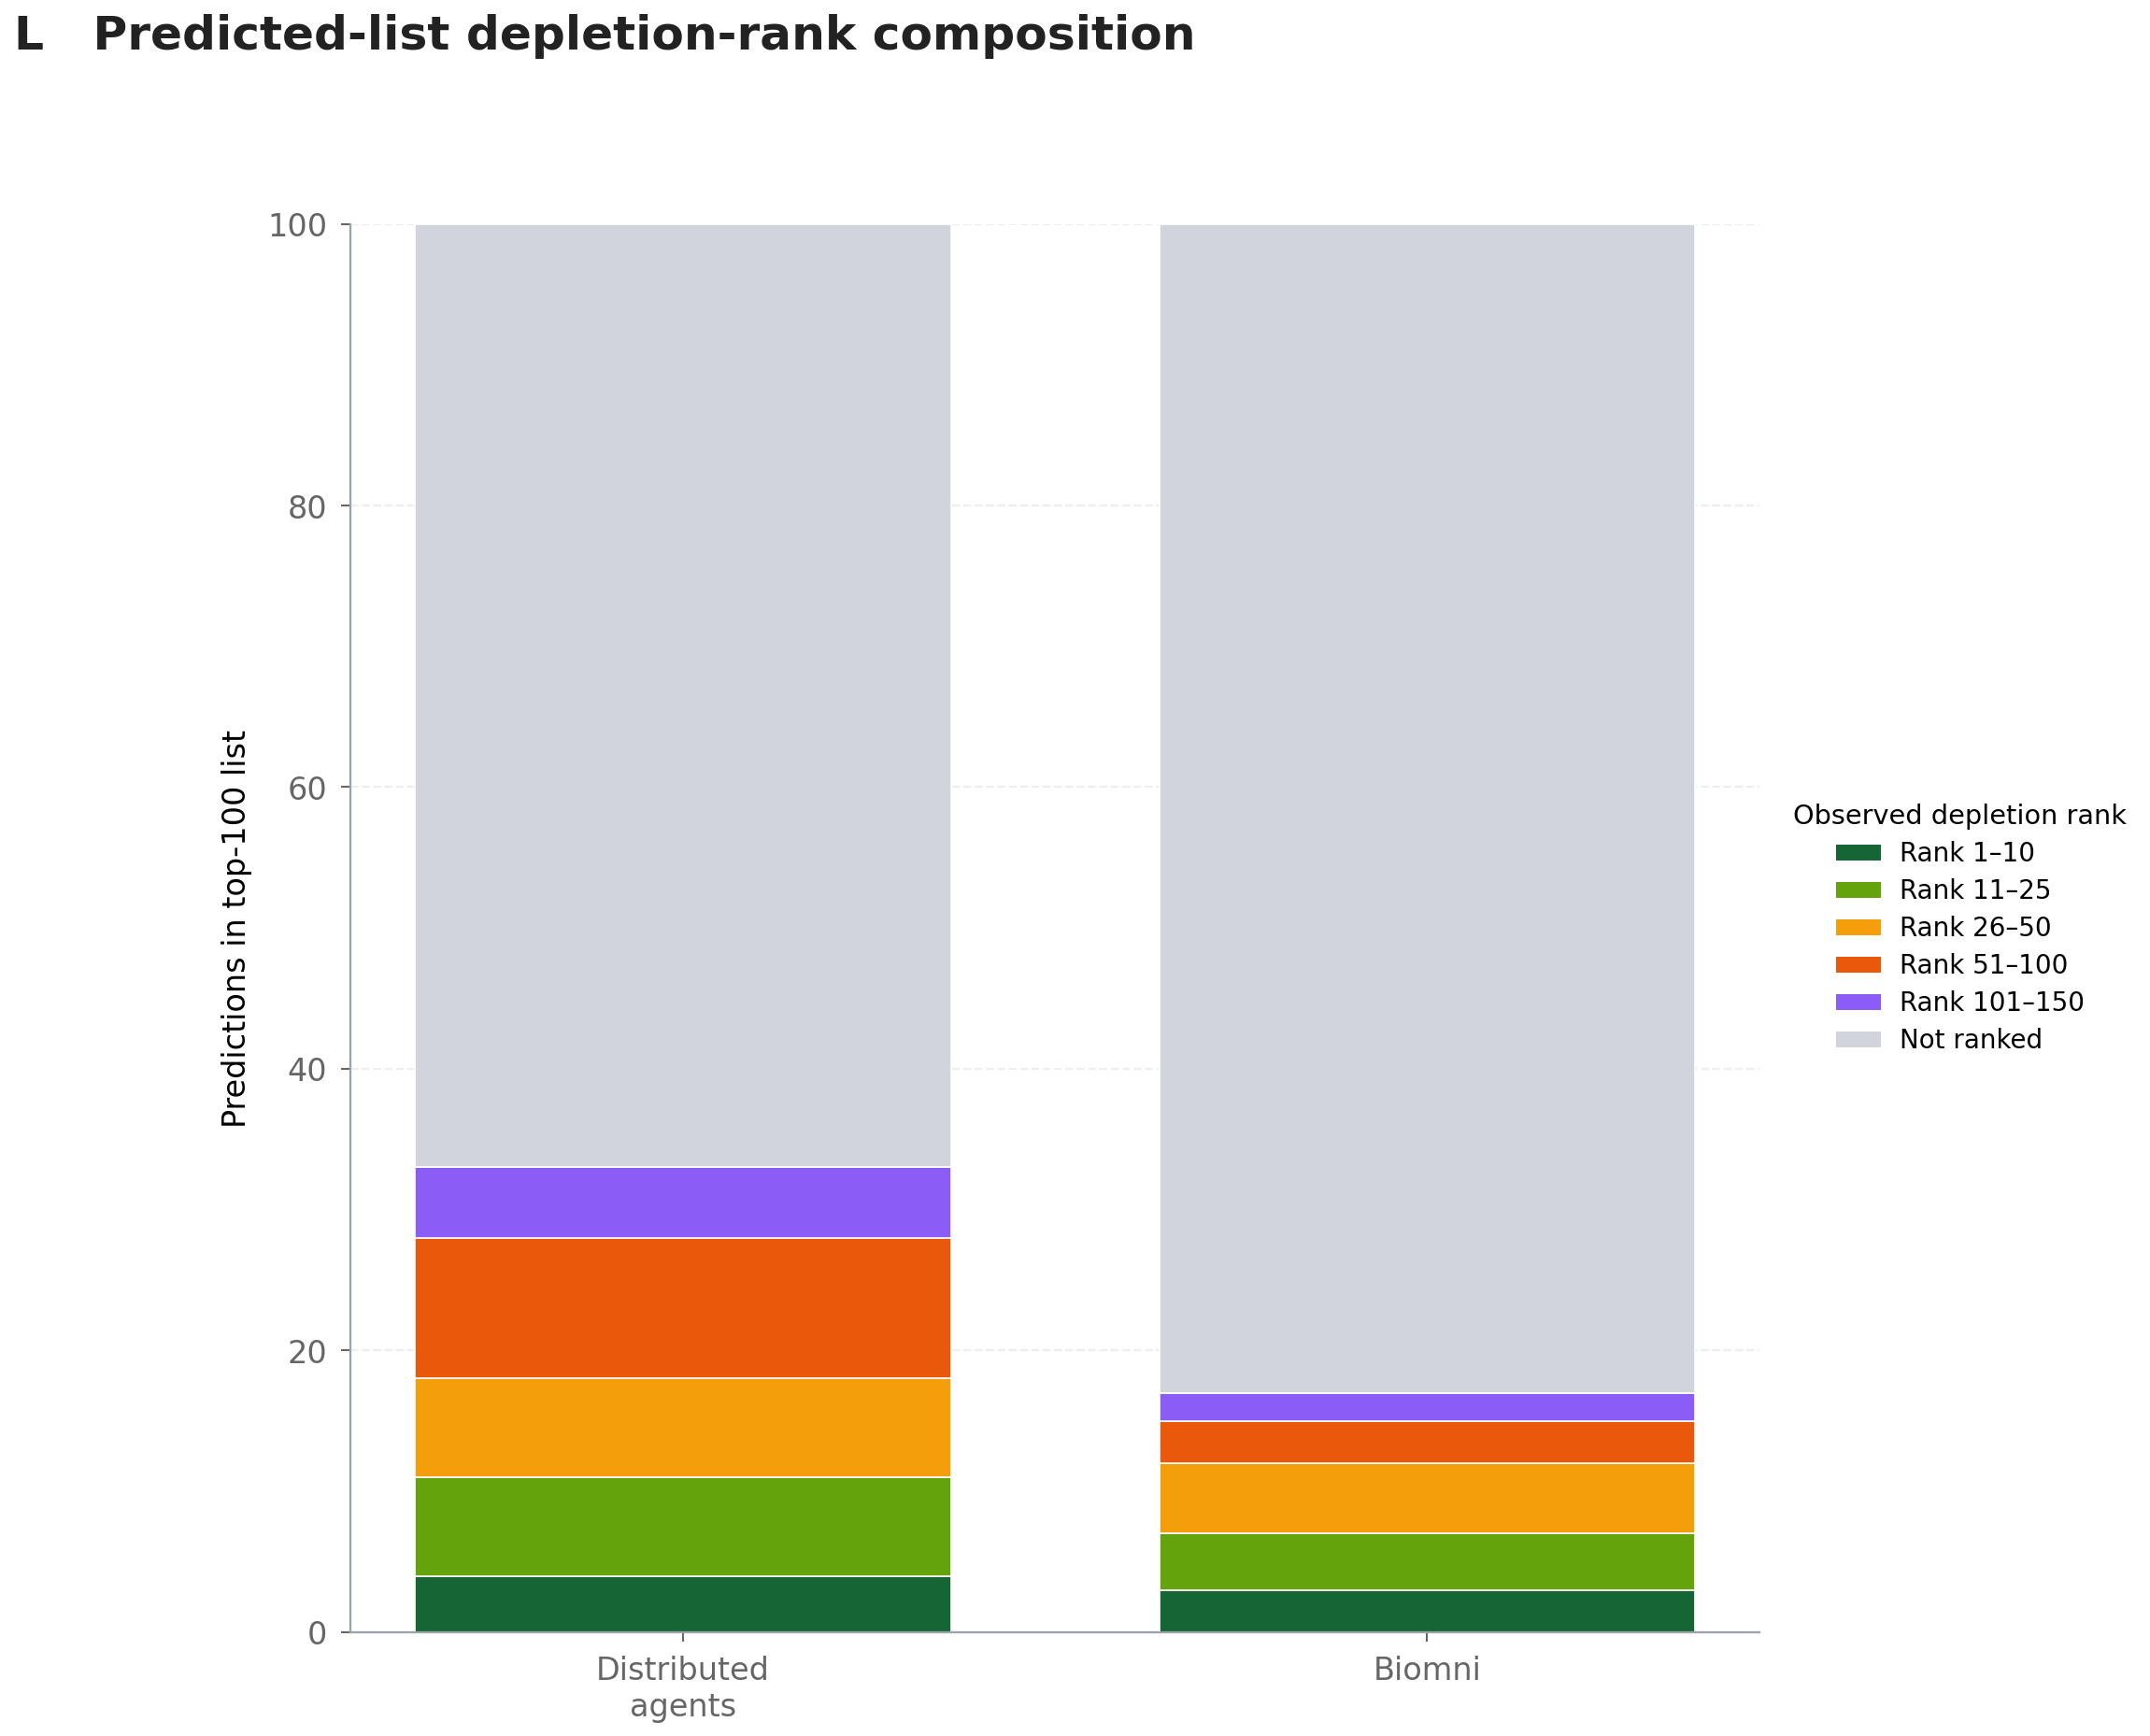

In [13]:
_CHROME = CHROME
_clean_axis = clean_axis
_heading = heading
_data = L_DATA.copy()
_data["gt_bin"] = _data["gt_bin"].fillna("Not ranked")
_framework_order = ("BioAgents q7b_v2", "q7b_r4")
_framework_labels = ("Distributed\nagents", "Biomni")
_bin_order = ("GT 1-10", "GT 11-25", "GT 26-50", "GT 51-100", "GT 101-150", "Not ranked")
_bin_labels = {
    "GT 1-10": "Rank 1–10",
    "GT 11-25": "Rank 11–25",
    "GT 26-50": "Rank 26–50",
    "GT 51-100": "Rank 51–100",
    "GT 101-150": "Rank 101–150",
    "Not ranked": "Not ranked",
}
_bin_colors = {
    "GT 1-10": "#166534",
    "GT 11-25": "#65a30d",
    "GT 26-50": "#f59e0b",
    "GT 51-100": "#ea580c",
    "GT 101-150": "#8b5cf6",
    "Not ranked": "#d1d5db",
}

# ------------------------------------------------------------------ L
def draw_l(container):
    _heading(container, "L", "Predicted-list depletion-rank composition")
    ax = container.subplots()
    _counts = (
        _data.groupby(["framework", "gt_bin"])
        .size()
        .unstack(fill_value=0)
        .reindex(index=list(_framework_order), columns=list(_bin_order), fill_value=0)
    )
    _x = np.arange(len(_framework_order))
    _bottom = np.zeros(len(_framework_order))
    for _key in _bin_order:
        _values = _counts[_key].to_numpy(dtype=float)
        ax.bar(_x, _values, bottom=_bottom, color=_bin_colors[_key], width=0.72, edgecolor="white", linewidth=0.4)
        _bottom += _values
    ax.set_xticks(_x, _framework_labels)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Predictions in top-100 list")
    _clean_axis(ax, "y")
    ax.set_box_aspect(1)
    ax.legend(
        handles=[Patch(facecolor=_bin_colors[key], edgecolor="none", label=_bin_labels[key]) for key in _bin_order],
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
        fontsize=5.8,
        title="Observed depletion rank",
        title_fontsize=6.0,
    )

fig_l, outputs_l = save_panel("L", draw_l, (5.2, 4.5))
fig_l;